# Rozpoznawanie Emocji z Tekstu — Kompleksowa Analiza Porównawcza

---

## O projekcie

Celem projektu jest **kompleksowe porównanie różnych metod automatycznej klasyfikacji emocji w tekście** (anger, joy, sadness, fear). Projekt obejmuje pełny pipeline uczenia maszynowego — od wczytania i przetworzenia danych, przez trening 11 modeli z różnych rodzin (klasyczne ML, sieci rekurencyjne, transformery), aż po zaawansowane techniki wyjaśnialności (XAI).

Klasyfikacja emocji w tekście to zadanie z dziedziny **Natural Language Processing (NLP)**, które ma szerokie zastosowania praktyczne: analiza sentymentu w mediach społecznościowych, monitorowanie zdrowia psychicznego, systemy dialogowe czy analiza recenzji produktów.

---

## Mapa projektu — co się tutaj dzieje?

Notebook jest zorganizowany w **trzech głównych blokach**:

### Blok I — Opis modeli, Dane i przygotowanie środowiska
Wczytanie i balansowanie datasetów, czyszczenie tekstu, podział na zbiory train/val/test, analiza data leakage.

### Blok II — Trening i ewaluacja modeli (11 modeli z 4 rodzin)
Trening wszystkich modeli na głównym datasecie (Combined) i ewaluacja na trzech zbiorach testowych — w tym na danych spoza domeny (ISEAR, GoEmotions), których modele nigdy nie widziały.

### Blok III — Eksperymenty analityczne
Seria ukierunkowanych eksperymentów: analiza wpływu długości tekstu, wyjaśnialność predykcji (XAI), analiza błędów, połączenie datasetów (Dataset Fusion) i analiza kosztów obliczeniowych.

---

## Przeprowadzone eksperymenty

| # | Eksperyment | Co sprawdzamy? |
|---|---|---|
| **Exp 1** | **Data Leakage Analysis** | Czy dane testowe nie wyciekły do zbioru treningowego? |
| **Exp 2** | **Ewaluacja out-of-domain** | Jak modele radzą sobie na danych których nigdy nie widziały (ISEAR, GoEmotions)? |
| **Exp 3** | **Porównanie 11 modeli** | Który model jest najlepszy i dlaczego? Benchmark wszystkich podejść. |
| **Exp 4** | **Analiza czasów trenowania** | Ile kosztuje wytrenowanie każdego modelu? Czy jakość uzasadnia koszt? |
| **Exp 5** | **Wpływ długości tekstu** | Czy krótkie lub długie zdania są trudniejsze do klasyfikacji? |
| **Exp 6** | **XAI (LIME + Integrated Gradients)** | Które słowa w tekście decydują o predykcji modelu? |
| **Exp 7** | **Analiza błędnych klasyfikacji** | Jakie próbki mylą **wszystkie** najlepsze modele jednocześnie? |
| **Exp 8** | **Dataset Fusion** | Czy łączenie datasetów z różnych źródeł poprawia generalizację? |

---

## Struktura katalogów

```
projekt/
├── checkpoints/           ← zapisane modele (.joblib, .pt, .safetensors)
├── plots/                 ← wykresy (PNG)
└── reports/               ← CSV z metrykami, rankingi, czasy trenowania
```

---

## Wymagania środowiskowe

- Python 3.9+, PyTorch 2.x, CUDA (zalecane — bez GPU czasy trenowania transformerów rosną 10-50×)
- Biblioteki: `transformers`, `torch`, `scikit-learn`, `lime`, `captum`, `seaborn`, `tqdm`
- podzespoły: liczone na 16 GB RAM i 8 GB VRAM

---


## Blok I — Dane

---

### 1.1 Źródła danych (datasety)

W projekcie używanych jest piec publicznych datasetow z emocjami w tekście angielskim.

| Dataset | Link | Próbki | Opis |
|---|---|---|---|
| **Combined** | [Kaggle](https://www.kaggle.com/datasets/kushagra3204/sentiment-and-emotion-analysis-dataset) | ~422k (→ 40k po balansowaniu) | Główny zbiór treningowy. 6 emocji zredukowanych do 4 klas. Zbalansowany: 10k próbek/klasę. |
| **ISEAR** | [Kaggle](https://www.kaggle.com/datasets/faisalsanto007/isear-dataset) | ~4.3k | Opisy sytuacji emocjonalnych z badań psychologicznych. Inny styl języka niż Combined — dobre źródło out-of-domain. |
| **GoEmotions** | [Kaggle](https://www.kaggle.com/datasets/debarshichanda/goemotions) | ~11k | Komentarze z Reddita (27 emocji → 4). Język potoczny, skróty, sarkazm. Najtrudniejszy do klasyfikacji. |
| **Praveen** | [Kaggle](https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp) | ~13k | "Collection of documents and its emotions" |
| **Tripathi** | [Kaggle](https://www.kaggle.com/datasets/anjaneyatripathi/emotion-classification-nlp) | ~23k | Nie wiadomo |
| **Fusion: All Three** | — | ~55k | Combined + ISEAR + GoEmotions — maksymalna różnorodność domenowa danych treningowych. |


> **Dlaczego 4 klasy?** Oryginalne datasety zawierają 6–27 emocji. Na potrzeby porównywalności i zbalansowania wybrano 4 klasy wspólne dla wszystkich zbiorów: **anger**, **joy**, **sadness**, **fear**.

---

### 1.2 Preprocessing tekstu

Każdy tekst przechodzi przez pipeline czyszczenia:
- zamiana URL-i na token `URL`
- zamiana wzmianek `@user` na token `USER`
- usunięcie `#` z hashtagów
- normalizacja białych znaków

---


### 1.3 Przegląd modeli — klasyczne ML i sieci rekurencyjne

Modele klasyczne i rekurencyjne stanowią **punkt odniesienia (baseline)** dla transformerów. Są szybsze i mniej zasobożerne, ale generalnie osiągają niższe wyniki na zadaniach NLP.

| Model | Typ | Architektura | Opis |
|---|---|---|---|
| **SVM** | Klasyczny ML | LinearSVC + TF-IDF (unigramy + bigramy) | Liniowy SVM ze zbalansowanymi wagami klas. Bardzo szybki, silny baseline dla danych tekstowych. |
| **Decision Tree** | Klasyczny ML | Drzewo decyzyjne (max_depth=50) | Prosty, w pełni interpretowalny model. Podatny na overfitting przy dużych słownikach TF-IDF. |
| **Naive Bayes** | Klasyczny ML | MultinomialNB + TF-IDF | Klasyfikator bayesowski zakładający niezależność cech. Bardzo szybki — dobry baseline. |
| **BiLSTM** | Rekurencyjny | Dwukierunkowy LSTM (2 warstwy, hidden=128, embed=128) | Przetwarza tekst w obu kierunkach → lepiej łapie kontekst niż jednokierunkowe RNN. |
| **BiGRU** | Rekurencyjny | Dwukierunkowy GRU (2 warstwy, hidden=128, embed=128) | Podobny do BiLSTM, prostsza bramka, szybszy trening, porównywalne wyniki. |

> **Reprezentacja tekstu dla modeli klasycznych:** TF-IDF (Term Frequency–Inverse Document Frequency) — każde zdanie to wektor ważonych częstości słów. Słownik: 15k tokenów, unigramy i bigramy.

---


### 1.4 Przegląd modeli — Transformery

Transformery to aktualnie najskuteczniejsza rodzina modeli NLP. Każdy z nich był **fine-tunowany** na zadaniu klasyfikacji 4 emocji (z wyjątkiem modeli pretrenowanych z HuggingFace).

| Model | HF Link | Tensor type | Rozmiar | Uwagi |
|---|---|---|---|---|
| **Own-DistilBERT** | [distilbert-base-uncased](https://huggingface.co/distilbert-base-uncased) | F32 | 67M | Fine-tuned na Combined. Lekka wersja BERT — 40% mniej parametrów, zachowuje ~97% jakości. |
| **Own-DistilRoBERTa** | [distilroberta-base](https://huggingface.co/distilroberta-base) | F32 | 82.8M | Fine-tuned na Combined. RoBERTa trenowana bez NSP, lepiej na zadaniach klasyfikacji. |
| **Own-DeBERTaV3** | [microsoft/deberta-v3-base](https://huggingface.co/microsoft/deberta-v3-base) | F32 | 184M | Fine-tuned na Combined. Najnowsza architektura — disentangled attention, najlepsza jakość. |
| **Fusion-DistilBERT** | [distilbert-base-uncased](https://huggingface.co/distilbert-base-uncased) | F32 | 67M | Fine-tuned na trzech połączonych datasetach (Combined + ISEAR + GoEmotions). Większa różnorodność treningowa. |
| **Fusion-DistilRoBERTa** | [distilroberta-base](https://huggingface.co/distilroberta-base) | F32 | 82.8M | Fine-tuned na trzech połączonych datasetach. |
| **Fusion-DeBERTaV3** | [microsoft/deberta-v3-base](https://huggingface.co/microsoft/deberta-v3-base) | F32 | 184M | Fine-tuned na trzech połączonych datasetach. Oczekiwana najlepsza generalizacja. |
| **Emotion-RoBERTa** | [SamLowe/roberta-base-go_emotions](https://huggingface.co/SamLowe/roberta-base-go_emotions) | F32 | ~125M | Gotowy z HuggingFace — trenowany na GoEmotions, tylko inferencja, bez fine-tuningu. |
| **Emotion-BERT** | [bhadresh-savani/bert-base-uncased-emotion](https://huggingface.co/bhadresh-savani/bert-base-uncased-emotion) | F32 | ~110M | Gotowy z HuggingFace — trenowany na nieznanym datasecie. Punkt odniesienia. |
| **Emotion-DeBERTaV3** | [HalogenFlo/...](https://huggingface.co/HalogenFlo/microsoft-deberta-v3-base-emotion-recognition) | F32 | ~184M | Gotowy z HuggingFace — DeBERTaV3 na rozpoznawaniu emocji. |

**Legenda typów tensorów:**
- **F32** — float32 (pełna precyzja, 4B/parametr) — najdokładniejszy, wymaga więcej VRAM
- **F16** — float16 (połowa precyzji, 2B/parametr) — oszczędza VRAM kosztem minimalnej utraty dokładności; używany gdy `use_fp16=True`

---


## Konfiguracja środowiska

Poniższe komórki instalują zależności (odkomentuj jeśli potrzeba), importują biblioteki i ustawiają wszystkie hiperparametry projektu w jednym słowniku `CONFIG`.

Kluczowe parametry:
- `samples_per_class` — ile próbek na klasę (mniej = szybciej, ale słabsze modele)
- `batch_size_tfm` — rozmiar batcha dla transformerów (zmniejsz jeśli brakuje VRAM)
- `active_models` — lista modeli do trenowania (usuń niepotrzebne, by przyspieszyć)
- `use_fp16` — mixed precision (zalecane na GPU Ampere+)

---


In [1]:
# Instalacja zależności
# !pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm joblib transformers accelerate evaluate torch torchtext captum lime

In [2]:
import os, re, json, math, random, warnings
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, balanced_accuracy_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_context('notebook')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'DEVICE: {DEVICE}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB' if torch.cuda.is_available() else 'CPU mode')

DEVICE: cuda  |  VRAM: 8.6GB


In [3]:
# ===== KONFIGURACJA =====
# samples_per_class: ile próbek NA KLASĘ (4 klasy) -> total = samples_per_class * 4
# max_features_tfidf: rozmiar słownika TF-IDF (mniej = mniej RAM)
# batch_size: dla RNN
# batch_size_tfm: dla transformerów (8-16 na 8GB VRAM)
# tfm_max_len: długość tokenów (krócej = mniej VRAM)
# use_fp16: True = mieszana precyzja (oszczędza VRAM)
# active_models: które modele trenować (listę stringów)

PROJECT_ROOT = Path('.')
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'
PLOTS_DIR = PROJECT_ROOT / 'plots'
REPORTS_DIR = PROJECT_ROOT / 'reports'

import time
from datetime import datetime
TRAINING_TIMES_PATH = REPORTS_DIR / 'training_times.json'
if TRAINING_TIMES_PATH.exists():
    training_times = json.loads(TRAINING_TIMES_PATH.read_text())
else:
    training_times = {}

def save_training_time(model_name, seconds):
    training_times[model_name] = {'training_time_sec': round(seconds, 1), 'timestamp': str(datetime.now())}
    TRAINING_TIMES_PATH.write_text(json.dumps(training_times, indent=2))
    print(f'  [Timing] {model_name}: {seconds:.1f}s')

for d in [DATA_DIR, CHECKPOINT_DIR, PLOTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # Ścieżki danych
    'combined_path': '../data/project_data/reduced/combined_red.csv',
    'isear_path': '../data/project_data/reduced/isear_red.csv',
    'goemotions_path': '../data/project_data/reduced/goemotions_red.csv',  # jeśli None, GoEmotions będzie pominięty w ewaluacji
    'praveen_path': '../data/project_data/reduced/praveen_red.csv',
    'tripathi_path': '../data/project_data/reduced/tripathi_red.csv',

    # Cele
    'target_emotions': ['anger', 'joy', 'sadness', 'fear'],

    # Balansowanie
    'samples_per_class': 10000,  # -> 60k total. Zmień na 5000-10000 jeśli brakuje RAM

    # TF-IDF dla klasycznych modeli
    'max_features_tfidf': 3000,
    'ngram_range': (1, 2),
    'min_df': 5,

    # RNN
    'max_seq_len_rnn': 80,
    'embed_dim': 128,
    'hidden_dim': 128,
    'batch_size': 32,
    'rnn_epochs': 10,
    'learning_rate_rnn': 2e-3,

    # Transformery
    'tfm_max_len': 64,
    'batch_size_tfm': 8,
    'transformer_epochs': 3,
    'learning_rate_transformer': 2e-5,
    'use_fp16': True,

    # Modele HF do fine-tuningu
    'hf_models_to_finetune': {
        'Own-DistilBERT': 'distilbert-base-uncased',
        'Own-DistilRoBERTa': 'distilroberta-base',
        'Own-DeBERTaV3': 'microsoft/deberta-v3-base',
    },
    'pretrained_emotion_roberta': 'SamLowe/roberta-base-go_emotions',
    'pretrained_emotion_bert': 'bhadresh-savani/bert-base-uncased-emotion',
    'pretrained_emotion_deberta': 'HalogenFlo/microsoft-deberta-v3-base-emotion-recognition',

    # Które modele uruchomić (stringi)
    # 'SVM', 'DecisionTree', 'NaiveBayes', 'BiLSTM', 'BiGRU',
    # 'Own-DistilBERT', 'DistilRoBERTa', 'BERT', 'RoBERTa', 'Pretrained'
    'active_models': ['SVM', 'DecisionTree', 'NaiveBayes', 'BiLSTM', 'BiGRU', 'Own-DistilBERT', 'Own-DistilRoBERTa', 'Own-DeBERTaV3', 'Pretrained'],

    # XAI
    'xai_n_examples': 30,
    'xai_top_k': 10,

    # Quick test: True = ewaluacja na malych probkach (szybko), False = pelny zbior
    'quick_test': False,
    'quick_test_samples': 200,
}

print(json.dumps(CONFIG, indent=2, default=str))
total = CONFIG['samples_per_class'] * len(CONFIG['target_emotions'])
print(f'\nTotal samples po zbalansowaniu: ~{total}k ({CONFIG["samples_per_class"]} per class)')

{
  "combined_path": "../data/project_data/reduced/combined_red.csv",
  "isear_path": "../data/project_data/reduced/isear_red.csv",
  "goemotions_path": "../data/project_data/reduced/goemotions_red.csv",
  "praveen_path": "../data/project_data/reduced/praveen_red.csv",
  "tripathi_path": "../data/project_data/reduced/tripathi_red.csv",
  "target_emotions": [
    "anger",
    "joy",
    "sadness",
    "fear"
  ],
  "samples_per_class": 10000,
  "max_features_tfidf": 3000,
  "ngram_range": [
    1,
    2
  ],
  "min_df": 5,
  "max_seq_len_rnn": 80,
  "embed_dim": 128,
  "hidden_dim": 128,
  "batch_size": 32,
  "rnn_epochs": 10,
  "learning_rate_rnn": 0.002,
  "tfm_max_len": 64,
  "batch_size_tfm": 8,
  "transformer_epochs": 3,
  "learning_rate_transformer": 2e-05,
  "use_fp16": true,
  "hf_models_to_finetune": {
    "Own-DistilBERT": "distilbert-base-uncased",
    "Own-DistilRoBERTa": "distilroberta-base",
    "Own-DeBERTaV3": "microsoft/deberta-v3-base"
  },
  "pretrained_emotion_robert

---

## Wczytywanie danych

Wczytujemy trzy datasety i balansujemy Combined do `samples_per_class` próbek na klasę. ISEAR i GoEmotions są wczytywane w oryginalnej postaci jako zbiory out-of-domain.

Po wczytaniu wizualizujemy rozkład klas, żeby upewnić się że dane są zbalansowane.

---


## 1. Wczytywanie i balansowanie Combined datasetu

In [4]:
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_combined(path, emotions, samples_per_class):
    df = pd.read_csv(path)
    # znajdź kolumny
    text_col = [c for c in df.columns if c.lower() in ('text','sentence','content')]
    label_col = [c for c in df.columns if c.lower() in ('emotion','label','sentiment')]
    if not text_col or not label_col:
        raise ValueError(f'Kolumny: {list(df.columns)}')
    out = pd.DataFrame({
        'text': df[text_col[0]].map(clean_text),
        'emotion': df[label_col[0]].str.strip().str.lower(),
    })
    out = out[out['emotion'].isin(emotions)]
    out = out.dropna(subset=['text', 'emotion'])
    out = out[out['text'].str.len() > 0].drop_duplicates(subset=['text'])
    # balansowanie: sample per class
    balanced = []
    for e in emotions:
        subset = out[out['emotion'] == e]
        if len(subset) >= samples_per_class:
            subset = subset.sample(samples_per_class, random_state=SEED)
        else:
            subset = subset.sample(frac=1, replace=True, random_state=SEED)[:samples_per_class]
        balanced.append(subset)
    result = pd.concat(balanced, ignore_index=True)
    return result.sample(frac=1, random_state=SEED).reset_index(drop=True)

def load_external(path, emotions, label='dataset_name'):
    if not path or not Path(path).exists():
        return None
    df = pd.read_csv(path)
    text_col = [c for c in df.columns if c.lower() in ('text','sentence','content')]
    label_col = [c for c in df.columns if c.lower() in ('emotion','label','sentiment')]
    if not text_col or not label_col:
        return None
    out = pd.DataFrame({
        'text': df[text_col[0]].map(clean_text),
        'emotion': df[label_col[0]].str.strip().str.lower(),
    })
    out = out[out['emotion'].isin(emotions)]
    out = out.dropna(subset=['text', 'emotion'])
    out = out[out['text'].str.len() > 0].drop_duplicates(subset=['text'])
    return out.reset_index(drop=True)

print('Ładowanie Combined...')
combined = load_combined(CONFIG['combined_path'], CONFIG['target_emotions'], CONFIG['samples_per_class'])
print(f'Combined zbalansowany: {len(combined)} próbek')
print(combined['emotion'].value_counts())

print('\nŁadowanie ISEAR...')
isear = load_external(CONFIG['isear_path'], CONFIG['target_emotions'])
if isear is not None:
    print(f'ISEAR: {len(isear)} próbek')
    print(isear['emotion'].value_counts())

print('\nŁadowanie GoEmotions...')
goemotions = load_external(CONFIG['goemotions_path'], CONFIG['target_emotions'])
if goemotions is not None:
    print(f'GoEmotions: {len(goemotions)} próbek')
    print(goemotions['emotion'].value_counts())

print('\nŁadowanie Praveen...')
praveen = load_external(CONFIG['praveen_path'], CONFIG['target_emotions'])
if praveen is not None:
    print(f'Praveen: {len(praveen)} próbek')

print('\nŁadowanie Tripathi...')
tripathi = load_external(CONFIG['tripathi_path'], CONFIG['target_emotions'])
if tripathi is not None:
    print(f'Tripathi: {len(tripathi)} próbek')

Ładowanie Combined...
Combined zbalansowany: 40000 próbek
emotion
fear       10000
joy        10000
sadness    10000
anger      10000
Name: count, dtype: int64

Ładowanie ISEAR...
ISEAR: 4284 próbek
emotion
joy        1080
anger      1078
fear       1072
sadness    1054
Name: count, dtype: int64

Ładowanie GoEmotions...
GoEmotions: 11092 próbek
emotion
anger      3833
joy        3317
sadness    2757
fear       1185
Name: count, dtype: int64

Ładowanie Praveen...
Praveen: 17627 próbek

Ładowanie Tripathi...
Tripathi: 6863 próbek


---

## Eksperyment 1 — Data Leakage Analysis

**Pytanie badawcze:** Czy próbki z datasetów testowych (ISEAR, GoEmotions, Praveen, Tripathi) przypadkowo trafiły do zbioru treningowego (Combined)?

**Dlaczego to ważne?**  
Data leakage (wyciek danych) polega na tym, że model widzi podczas treningu te same przykłady, które później pojawiają się w zbiorze testowym. W takiej sytuacji wyniki testowe są sztucznie zawyżone i nie odzwierciedlają rzeczywistych możliwości modelu.

**Sprawdzamy cztery scenariusze:**

| Metoda | Co wykrywa? |
|---|---|
| **Exact match** | Identyczne zdania w train i test |
| **Normalized match** | Jak wyżej, po usunięciu interpunkcji i unifikacji wielkości liter |
| **Konflikty etykiet** | Ten sam tekst, ale z różnymi emocjami w różnych datasetach |
| **Near-duplikaty (Jaccard ≥ 0.8)** | Niemal identyczne zdania — różniące się np. pojedynczym słowem |

> Wynik tego eksperymentu jest warunkiem poprawności wszystkich dalszych eksperymentów.

---


In [5]:
def analyze_data_leakage(combined, isear, goemotions, praveen=None, tripathi=None):
    import re as _re
    from collections import defaultdict

    datasets = {}
    if combined is not None:
        datasets['Combined (train/val)'] = combined
    if isear is not None:
        datasets['ISEAR (test)'] = isear
    if goemotions is not None:
        datasets['GoEmotions (test)'] = goemotions
    if praveen is not None:
        datasets['Praveen (test)'] = praveen
    if tripathi is not None:
        datasets['Tripathi (test)'] = tripathi

    names = list(datasets.keys())
    print('=' * 70)
    print('DATA LEAKAGE ANALYSIS — sprawdzenie czy próbki się powtarzają')
    print('=' * 70)
    print('\nDatasety:')
    for n in names:
        print(f'  {n}: {len(datasets[n])} próbek')

    # ── 1. EXACT TEXT MATCH ──
    print(f'\n{"─" * 70}')
    print('1. DUPLIKATY TEKSTÓW (exact match) między parami datasetów')
    print(f'{"─" * 70}')

    overlap_summary = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            name_a, name_b = names[i], names[j]
            df_a, df_b = datasets[name_a], datasets[name_b]
            texts_a = set(df_a['text'].str.strip().str.lower())
            texts_b = set(df_b['text'].str.strip().str.lower())
            overlap = texts_a & texts_b

            print(f'\n  {name_a}  vs  {name_b}')
            print(f'  {"─" * 50}')
            print(f'  Wspólne próbki: {len(overlap)}')

            if len(overlap) > 0:
                pct_a = len(overlap) / len(df_a) * 100
                pct_b = len(overlap) / len(df_b) * 100
                print(f'  → {pct_a:.4f}% z "{name_a}" wycieka do "{name_b}"')
                print(f'  → {pct_b:.4f}% z "{name_b}" wycieka do "{name_a}"')
                overlap_in_a = df_a[df_a['text'].str.strip().str.lower().isin(overlap)]
                print(f'\n  Wyciek według emocji (z perspektywy {name_a}):')
                for emo, cnt in overlap_in_a['emotion'].value_counts().items():
                    print(f'    {emo:15s}: {cnt}')
                print(f'\n  Przykłady wyciekających tekstów (max 5):')
                for _, row in overlap_in_a.head(5).iterrows():
                    txt = row['text'] if len(row['text']) <= 90 else row['text'][:87] + '...'
                    print(f'    [{row["emotion"]:8s}] {txt}')
                overlap_summary.append({'pair': f'{name_a} ↔ {name_b}', 'n_overlap': len(overlap), 'pct_a': pct_a, 'pct_b': pct_b})
            else:
                print(f'  ✓ BRAK wycieku danych między tymi datasetami!')

    # ── 2. NORMALIZED TEXT MATCH ──
    print(f'\n{"─" * 70}')
    print('2. NORMALIZOWANY TEKST (usunięta interpunkcja/wielkie litery/spacje) — FULL')
    print(f'{"─" * 70}')

    def normalize(t):
        t = _re.sub(r'[^a-zA-Z0-9 ]', '', t)
        t = _re.sub(r'\s+', ' ', t).strip().lower()
        return t

    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            name_a, name_b = names[i], names[j]
            df_a, df_b = datasets[name_a], datasets[name_b]
            norm_a = set(df_a['text'].apply(normalize))
            norm_b = set(df_b['text'].apply(normalize))
            exact_overlap = set(df_a['text'].str.strip().str.lower()) & set(df_b['text'].str.strip().str.lower())
            extra_overlap = (norm_a & norm_b) - exact_overlap

            print(f'\n  {name_a}  vs  {name_b}')
            print(f'  {"─" * 50}')
            if extra_overlap:
                print(f'  ⚠ Dodatkowe pary po normalizacji: {len(extra_overlap)}')
                norm_a_df = df_a.copy()
                norm_a_df['_norm'] = df_a['text'].apply(normalize)
                extra_in_a = norm_a_df[norm_a_df['_norm'].isin(extra_overlap)]
                for _, row in extra_in_a.head(3).iterrows():
                    txt = row['text'] if len(row['text']) <= 90 else row['text'][:87] + '...'
                    print(f'    [{row["emotion"]:8s}] {txt}')
            else:
                print(f'  ✓ Brak dodatkowych trafień po normalizacji')

    # ── 3. IN-CLASS LABEL LEAK ──
    print(f'\n{"─" * 70}')
    print('3. KONFLIKTY EMOCJI — ten sam tekst, różne etykiety w różnych datasetach')
    print(f'{"─" * 70}')

    all_text_to_emotions = defaultdict(set)
    for name, df in datasets.items():
        for _, row in df.iterrows():
            all_text_to_emotions[row['text'].strip().lower()].add((row['emotion'], name))

    conflicts = {k: v for k, v in all_text_to_emotions.items() if len(v) > 1}
    if conflicts:
        print(f'  ⚠ Znaleziono {len(conflicts)} tekstów z różnymi etykietami:')
        for txt, labels in list(conflicts.items())[:5]:
            print(f'    "{txt[:70]}..."')
            for emo, ds in labels:
                print(f'      → {emo:10s} (z {ds})')
    else:
        print(f'  ✓ Brak konfliktów etykiet')

    # ── 4. DUPLICATES WITHIN Combined ──
    print(f'\n{"─" * 70}')
    print('4. DUPLIKATY WEWNĄTRZ Combined (z balansowania z replace=True)')
    print(f'{"─" * 70}')
    if combined is not None:
        combined_lower = combined['text'].str.strip().str.lower()
        dup_mask = combined_lower.duplicated(keep=False)
        n_dups = dup_mask.sum()
        if n_dups > 0:
            dup_df = combined[dup_mask].sort_values('text')
            n_unique = combined_lower[dup_mask].nunique()
            print(f'  ⚠ Liczba duplikatów (wierszy): {n_dups} ({n_dups / len(combined) * 100:.2f}%)')
            print(f'  ⚠ Unikalnych zduplikowanych tekstów: {n_unique}')
            print(f'  Duplikaty według emocji:')
            print(f'  {dup_df["emotion"].value_counts().to_string()}')
            print(f'  Przykłady duplikatów (max 4):')
            seen = set()
            for _, row in dup_df.iterrows():
                t = row['text'].strip().lower()
                if t not in seen:
                    seen.add(t)
                    txt = row['text'] if len(row['text']) <= 90 else row['text'][:87] + '...'
                    print(f'    [{row["emotion"]:8s}] {txt}')
                    if len(seen) >= 4:
                        break
        else:
            print(f'  ✓ Brak duplikatów wewnątrz Combined')

    # ── 5. SMART JACCARD NEAR-DUP (inverted index, full dataset) ──
    print(f'\n{"─" * 70}')
    print('5. NEAR-DUPLIKATY JACCARD (inverted index — pełna analiza)')
    print(f'{"─" * 70}')

    STOPWORDS = {'a','about','after','again','all','also','am','an','and','any','are','as','at','be',
                 'because','been','before','being','between','both','but','by','can','could','did','do',
                 'does','done','due','during','each','few','for','from','further','had','has','have',
                 'having','here','how','i','if','in','into','is','it','its','just','like','made','make',
                 'may','me','more','most','much','my','no','nor','not','now','of','on','once','only',
                 'or','other','our','out','over','own','per','put','said','same','should','show','shown',
                 'shows','than','that','the','their','them','there','these','they','this','those',
                 'through','to','too','under','up','upon','very','was','way','we','were','what','when',
                 'where','which','while','who','why','will','with','would','you','your'}

    for name, df in datasets.items():
        texts = df['text'].str.strip().str.lower().values
        inverted = defaultdict(list)
        for idx, t in enumerate(texts):
            words = [w for w in set(t.split()) if len(w) > 2 and w not in STOPWORDS]
            for w in words:
                inverted[w].append(idx)

        candidates = defaultdict(set)
        for word, indices in inverted.items():
            if len(indices) > 500:
                continue
            for ii in range(len(indices)):
                for jj in range(ii + 1, len(indices)):
                    a, b = indices[ii], indices[jj]
                    if b - a < 10000:
                        candidates[a].add(b)
                        candidates[b].add(a)

        near_dup_pairs = []
        checked = 0
        for i in range(len(texts)):
            for j in list(candidates.get(i, set())):
                if i >= j:
                    continue
                checked += 1
                if checked > 50000:
                    break
                words_i = set(texts[i].split())
                words_j = set(texts[j].split())
                union = len(words_i | words_j)
                if union < 3:
                    continue
                jaccard = len(words_i & words_j) / union
                if jaccard > 0.80 and texts[i] != texts[j]:
                    near_dup_pairs.append((jaccard, texts[i], texts[j], df.iloc[i]['emotion'], df.iloc[j]['emotion']))
            if checked > 50000:
                break

        near_dup_pairs.sort(reverse=True)

        print(f'\n  {name} ({len(df)} próbek)')
        print(f'  Sprawdzono {checked} par kandydackich | Znaleziono: {len(near_dup_pairs)}')
        if near_dup_pairs:
            print(f'  Przykłady (top 5):')
            for jac, t1, t2, e1, e2 in near_dup_pairs[:5]:
                t1d = t1 if len(t1) <= 65 else t1[:62] + '...'
                t2d = t2 if len(t2) <= 65 else t2[:62] + '...'
                print(f'    J={jac:.3f} [{e1}] "{t1d}"')
                print(f'             [{e2}] "{t2d}"')
        else:
            print(f'  ✓ Brak near-duplikatów')

    # ── 6. SUMMARY ──
    print(f'\n{"═" * 70}')
    print('PODSUMOWANIE DATA LEAKAGE')
    print(f'{"═" * 70}')
    if overlap_summary:
        print(f'{"Pair":35s} {"Overlap":>8s} {"% of A":>8s} {"% of B":>8s}')
        print(f'{"─" * 35} {"─" * 8} {"─" * 8} {"─" * 8}')
        for s in overlap_summary:
            print(f'{s["pair"]:35s} {s["n_overlap"]:>8d} {s["pct_a"]:>7.4f}% {s["pct_b"]:>7.4f}%')
    else:
        print('  ✓ Nie wykryto żadnych wycieków danych!')
    print(f'\nKomentarz: Data leakage występuje gdy te same próbki są w train i test.')
    print(f'  Duplikaty wewnątrz Combined z oversamplingu nie wpływają na test.')
    print(f'{"═" * 70}')

analyze_data_leakage(combined, isear, goemotions, praveen, tripathi)


DATA LEAKAGE ANALYSIS — sprawdzenie czy próbki się powtarzają

Datasety:
  Combined (train/val): 40000 próbek
  ISEAR (test): 4284 próbek
  GoEmotions (test): 11092 próbek
  Praveen (test): 17627 próbek
  Tripathi (test): 6863 próbek

──────────────────────────────────────────────────────────────────────
1. DUPLIKATY TEKSTÓW (exact match) między parami datasetów
──────────────────────────────────────────────────────────────────────

  Combined (train/val)  vs  ISEAR (test)
  ──────────────────────────────────────────────────
  Wspólne próbki: 1
  → 0.0025% z "Combined (train/val)" wycieka do "ISEAR (test)"
  → 0.0233% z "ISEAR (test)" wycieka do "Combined (train/val)"

  Wyciek według emocji (z perspektywy Combined (train/val)):
    anger          : 1

  Przykłady wyciekających tekstów (max 5):
    [anger   ] i got angry with a stranger in a train who behaved impertinently and immorally

  Combined (train/val)  vs  GoEmotions (test)
  ──────────────────────────────────────────────────


---

Dane Combined dzielone są w proporcji **70% train / 15% val / 15% test** ze stratyfikacją po klasie emocji, co gwarantuje równomierny rozkład w każdym zbiorze.

---


In [6]:
# Podział Combined na train/val/test
label_encoder = LabelEncoder()
combined['label'] = label_encoder.fit_transform(combined['emotion'])
label_names = list(label_encoder.classes_)
num_labels = len(label_names)
print('Klasy:', label_names)

train_df, temp_df = train_test_split(
    combined, test_size=0.3, stratify=combined['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'\nTest set label distribution:')
print(test_df['emotion'].value_counts())

# Przygotuj zewnętrzne zbiory testowe
def prepare_test_set(df, name):
    if df is None or len(df) == 0:
        return None
    df = df.copy()
    df['label'] = df['emotion'].map({l: i for i, l in enumerate(label_names)})
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
    print(f'{name}: {len(df)} próbek')
    return df

isear_test = prepare_test_set(isear, 'ISEAR')
goemotions_test = prepare_test_set(goemotions, 'GoEmotions')

joblib.dump(label_encoder, CHECKPOINT_DIR / 'label_encoder.joblib')

Klasy: ['anger', 'fear', 'joy', 'sadness']
Train: 28000, Val: 6000, Test: 6000

Test set label distribution:
emotion
sadness    1500
joy        1500
anger      1500
fear       1500
Name: count, dtype: int64
ISEAR: 4284 próbek
GoEmotions: 11092 próbek


['checkpoints/label_encoder.joblib']

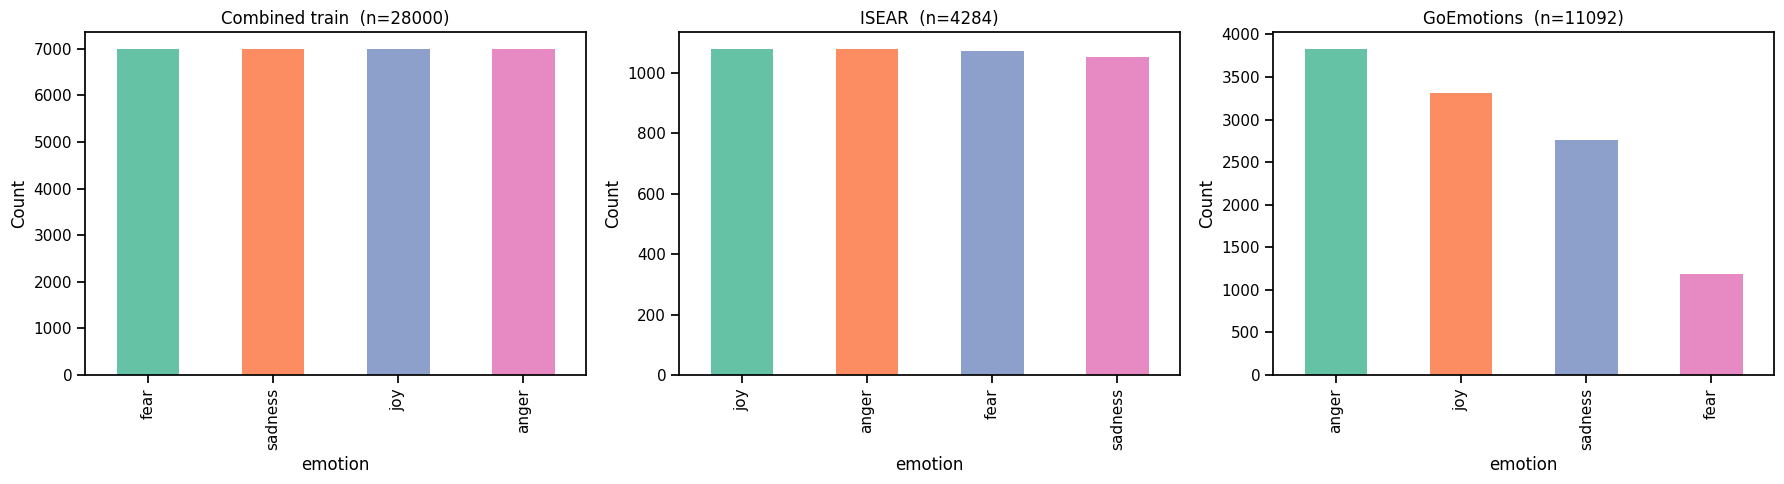

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, df) in zip(axes, [('Combined train', train_df), ('ISEAR', isear_test), ('GoEmotions', goemotions_test)]):
    if df is not None:
        df['emotion'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
        ax.set_title(f'{name}  (n={len(df)})')
        ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'dataset_distributions.png', dpi=150)
plt.show()

---

## Blok II — Trening i ewaluacja modeli

---

### Funkcje ewaluacji — wspólna infrastruktura

Wszystkie modele są oceniane tymi samymi funkcjami na tych samych zbiorach testowych, co gwarantuje **porównywalność wyników**.

**Metryki:**
- **Accuracy** — procent poprawnych klasyfikacji
- **Balanced Accuracy** — accuracy uwzględniające nierówny rozkład klas
- **Macro F1** — średnia F1 po klasach (każda klasa traktowana równo) — **główna metryka**
- **Weighted F1** — F1 ważona liczebnością klas

**Zbiory testowe:**
- `Combined_test` — hold-out z datasetu treningowego (in-domain)
- `ISEAR` — inny styl języka (out-of-domain)
- `GoEmotions` — język potoczny z Reddita (out-of-domain, najtrudniejszy)

---


## 2. Funkcje ewaluacji — wspólne dla wszystkich modeli

In [8]:
all_results = []  # lista słowników z metrykami per (model, dataset)
all_predictions = defaultdict(dict)  # model -> dataset -> {'y_true', 'y_pred', 'y_proba'}

# Zbiory ewaluacyjne
EVAL_SETS = {
    'Combined_test': test_df,
}
if isear_test is not None:
    EVAL_SETS['ISEAR'] = isear_test
if goemotions_test is not None:
    EVAL_SETS['GoEmotions'] = goemotions_test
if tripathi is not None:
    tripathi_test = prepare_test_set(tripathi, 'Tripathi')
    EVAL_SETS['Tripathi'] = tripathi_test

# Quick test: przytnij zbiory do quick_test_samples jesli wlaczone
if CONFIG['quick_test']:
    n = CONFIG['quick_test_samples']
    print(f'[Quick test] Ograniczam kazdy zbior do {n} probe')
    for k in list(EVAL_SETS.keys()):
        df = EVAL_SETS[k]
        if len(df) > n:
            grp = df.groupby('label', group_keys=False)
            EVAL_SETS[k] = grp.apply(lambda x: x.sample(min(len(x), n // df['label'].nunique()), random_state=SEED)).reset_index(drop=True)
            print(f'  {k}: {len(df)} -> {len(EVAL_SETS[k])}')

def evaluate_model(model_name: str, predict_fn, dataset_name: str, df):
    y_true = df['label'].values
    y_pred, y_proba = predict_fn(df['text'].tolist())
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    w_prec, w_rec, w_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    result = {
        'model': model_name,
        'dataset': dataset_name,
        'accuracy': acc,
        'balanced_accuracy': bacc,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'weighted_f1': w_f1,
    }
    all_results.append(result)
    all_predictions[model_name][dataset_name] = {'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba}
    return result

def eval_on_all_sets(model_name, predict_fn):
    print(f'\n=== {model_name} ===')
    for ds_name, ds_df in EVAL_SETS.items():
        res = evaluate_model(model_name, predict_fn, ds_name, ds_df)
        print(f'  {ds_name:20s}  acc={res["accuracy"]:.4f}  macro_f1={res["macro_f1"]:.4f}  w_f1={res["weighted_f1"]:.4f}')

def print_classification_report(model_name, dataset_name):
    d = all_predictions[model_name][dataset_name]
    print(classification_report(d['y_true'], d['y_pred'], target_names=label_names, zero_division=0))

def plot_confusion(model_name, dataset_name):
    d = all_predictions[model_name][dataset_name]
    cm = confusion_matrix(d['y_true'], d['y_pred'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title(f'{model_name} — {dataset_name}')
    plt.xlabel('Prediction'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'confusion_{model_name}_{dataset_name}.png', dpi=150)
    plt.show()

Tripathi: 6863 próbek


---

### Trening modeli klasycznych (SVM, Decision Tree, Naive Bayes)

Modele klasyczne używają reprezentacji **TF-IDF** tekstu. Pipeline: wektoryzacja TF-IDF → klasyfikator.

Modele są zapisywane do pliku `.joblib` — jeśli checkpoint istnieje, jest wczytywany (nie trenowany ponownie).

---


## 3. Klasyczne ML: SVM, Decision Tree, Naive Bayes

In [9]:
def train_classic_model(name, clf):
    path = CHECKPOINT_DIR / f'{name}.joblib'
    trained_now = False
    if path.exists():
        print(f'Loading {name} from {path}...')
        pipe = joblib.load(path)
    else:
        t0 = time.time()
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=CONFIG['max_features_tfidf'],
                ngram_range=CONFIG['ngram_range'],
                min_df=CONFIG['min_df']
            )),
            ('clf', clf)
        ])
        print(f'Training {name} on {len(train_df)} samples...')
        pipe.fit(train_df['text'].values, train_df['label'].values)
        joblib.dump(pipe, path)
        save_training_time(name, time.time() - t0)
        trained_now = True

    if not trained_now and name not in training_times:
        training_times[name] = {'training_time_sec': None, 'timestamp': 'loaded from checkpoint'}
        TRAINING_TIMES_PATH.write_text(json.dumps(training_times, indent=2))

    def predict_fn(texts):
        preds = pipe.predict(texts)
        if hasattr(pipe, 'predict_proba'):
            proba = pipe.predict_proba(texts)
        else:
            proba = None
        return preds, proba
    return predict_fn

classic_fns = {}
if 'SVM' in CONFIG['active_models']:
    classic_fns['SVM'] = train_classic_model('SVM', LinearSVC(class_weight='balanced', random_state=SEED, max_iter=2000))
if 'DecisionTree' in CONFIG['active_models']:
    classic_fns['DecisionTree'] = train_classic_model('DecisionTree', DecisionTreeClassifier(max_depth=200, min_samples_split=10, class_weight='balanced', random_state=SEED, min_samples_leaf=20))
if 'NaiveBayes' in CONFIG['active_models']:
    classic_fns['NaiveBayes'] = train_classic_model('NaiveBayes', MultinomialNB())

for name, fn in classic_fns.items():
    eval_on_all_sets(name, fn)

Loading SVM from checkpoints/SVM.joblib...
Loading DecisionTree from checkpoints/DecisionTree.joblib...
Loading NaiveBayes from checkpoints/NaiveBayes.joblib...

=== SVM ===
  Combined_test         acc=0.9508  macro_f1=0.9508  w_f1=0.9508
  ISEAR                 acc=0.5819  macro_f1=0.5832  w_f1=0.5835
  GoEmotions            acc=0.4501  macro_f1=0.4169  w_f1=0.4418
  Tripathi              acc=0.3906  macro_f1=0.3831  w_f1=0.3760

=== DecisionTree ===
  Combined_test         acc=0.9083  macro_f1=0.9080  w_f1=0.9080
  ISEAR                 acc=0.3824  macro_f1=0.3541  w_f1=0.3538
  GoEmotions            acc=0.4083  macro_f1=0.3199  w_f1=0.3375
  Tripathi              acc=0.3260  macro_f1=0.2654  w_f1=0.2617

=== NaiveBayes ===
  Combined_test         acc=0.9090  macro_f1=0.9090  w_f1=0.9090
  ISEAR                 acc=0.5854  macro_f1=0.5835  w_f1=0.5840
  GoEmotions            acc=0.4815  macro_f1=0.4494  w_f1=0.4795
  Tripathi              acc=0.3931  macro_f1=0.3809  w_f1=0.3772


---

### Trening sieci rekurencyjnych (BiLSTM, BiGRU)

Sieci rekurencyjne korzystają z własnego słownika (vocab) i embeddingów uczonych od zera. Architektura: embedding → dwukierunkowy LSTM/GRU (2 warstwy) → mean pooling → klasyfikator.

Trening trwa 10 epok z wczesnym zatrzymaniem na podstawie validation macro F1.

---


## 4. RNN: BiLSTM i BiGRU

In [10]:
class TextVocab:
    def __init__(self, max_size=30000, min_freq=2):
        self.max_size = max_size
        self.min_freq = min_freq
        self.stoi = {'<pad>': 0, '<unk>': 1}
        self.itos = ['<pad>', '<unk>']

    def tokenize(self, text):
        return re.findall(r"\b\w+\b|[^\w\s]", str(text).lower())

    def fit(self, texts):
        counter = Counter()
        for t in texts:
            counter.update(self.tokenize(t))
        for tok, freq in counter.most_common(self.max_size - 2):
            if freq >= self.min_freq:
                self.stoi[tok] = len(self.itos)
                self.itos.append(tok)
        return self

    def encode(self, text, max_len):
        ids = [self.stoi.get(tok, 1) for tok in self.tokenize(text)[:max_len]]
        ids += [0] * (max_len - len(ids))
        return ids

class RNNDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.texts = df['text'].tolist()
        self.labels = df['label'].values.astype(np.int64)
        self.vocab = vocab
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.vocab.encode(self.texts[idx], self.max_len), dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, rnn_type='lstm', dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(embed_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)
    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        out, _ = self.rnn(emb)
        mask = (input_ids != 0).unsqueeze(-1)
        out = out.masked_fill(~mask, 0.0)
        pooled = out.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.fc(self.dropout(pooled))

@torch.no_grad()
def predict_rnn(model, loader):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    for batch in loader:
        ids = batch['input_ids'].to(DEVICE)
        labels = batch['label'].cpu().numpy()
        logits = model(ids)
        proba = torch.softmax(logits, dim=-1).cpu().numpy()
        pred = proba.argmax(axis=1)
        y_true.extend(labels); y_pred.extend(pred); y_proba.extend(proba)
    return np.array(y_true), np.array(y_pred), np.array(y_proba)

def train_rnn(model_name, rnn_type):
    t0 = time.time()
    ckpt_path = CHECKPOINT_DIR / f'{model_name}.pt'
    if ckpt_path.exists():
        print(f'Loading {model_name} from {ckpt_path}...')
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        vocab = ckpt['vocab']
        model = BiRNNClassifier(len(vocab.itos), CONFIG['embed_dim'], CONFIG['hidden_dim'], num_labels, rnn_type=rnn_type).to(DEVICE)
        model.load_state_dict(ckpt['model_state'])
    else:
        vocab = TextVocab(max_size=30000, min_freq=2).fit(train_df['text'])
        train_ds = RNNDataset(train_df, vocab, CONFIG['max_seq_len_rnn'])
        val_ds = RNNDataset(val_df, vocab, CONFIG['max_seq_len_rnn'])
        train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], num_workers=0)

        model = BiRNNClassifier(len(vocab.itos), CONFIG['embed_dim'], CONFIG['hidden_dim'], num_labels, rnn_type=rnn_type).to(DEVICE)
        optim = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate_rnn'])
        criterion = nn.CrossEntropyLoss()
        best_val_f1 = -1
        train_losses = []

        for epoch in range(CONFIG['rnn_epochs']):
            model.train()
            losses = []
            for batch in tqdm(train_loader, desc=f'{model_name} ep.{epoch+1}'):
                ids = batch['input_ids'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                optim.zero_grad()
                logits = model(ids)
                loss = criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
                losses.append(loss.item())
            train_losses.append(np.mean(losses))

            y_val, p_val, _ = predict_rnn(model, val_loader)
            f1 = precision_recall_fscore_support(y_val, p_val, average='macro', zero_division=0)[2]
            print(f'{model_name} ep.{epoch+1}  loss={np.mean(losses):.4f}  val_macro_f1={f1:.4f}')
            if f1 > best_val_f1:
                best_val_f1 = f1
                torch.save({'model_state': model.state_dict(), 'vocab': vocab, 'epoch': epoch}, ckpt_path)

        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        save_training_time(model_name, time.time() - t0)
    if model_name not in training_times:
        training_times[model_name] = {'training_time_sec': None, 'timestamp': 'loaded from checkpoint'}
        TRAINING_TIMES_PATH.write_text(json.dumps(training_times, indent=2))
    def predict_fn(texts):
        ds = RNNDataset(pd.DataFrame({'text': texts, 'label': [0]*len(texts)}), vocab, CONFIG['max_seq_len_rnn'])
        loader = DataLoader(ds, batch_size=CONFIG['batch_size'], num_workers=0)
        _, y_pred, y_proba = predict_rnn(model, loader)
        return y_pred, y_proba
    return predict_fn

rnn_fns = {}
if 'BiLSTM' in CONFIG['active_models']:
    rnn_fns['BiLSTM'] = train_rnn('BiLSTM', 'lstm')
if 'BiGRU' in CONFIG['active_models']:
    rnn_fns['BiGRU'] = train_rnn('BiGRU', 'gru')

for name, fn in rnn_fns.items():
    eval_on_all_sets(name, fn)

Loading BiLSTM from checkpoints/BiLSTM.pt...
Loading BiGRU from checkpoints/BiGRU.pt...

=== BiLSTM ===
  Combined_test         acc=0.9748  macro_f1=0.9748  w_f1=0.9748
  ISEAR                 acc=0.5364  macro_f1=0.5290  w_f1=0.5292
  GoEmotions            acc=0.4463  macro_f1=0.3919  w_f1=0.4227
  Tripathi              acc=0.3615  macro_f1=0.3274  w_f1=0.3312

=== BiGRU ===
  Combined_test         acc=0.9728  macro_f1=0.9728  w_f1=0.9728
  ISEAR                 acc=0.5331  macro_f1=0.5292  w_f1=0.5295
  GoEmotions            acc=0.4399  macro_f1=0.3998  w_f1=0.4319
  Tripathi              acc=0.3702  macro_f1=0.3484  w_f1=0.3510


---

### Fine-tuning transformerów (DistilBERT, DistilRoBERTa, DeBERTaV3)

Transformery są fine-tunowane przy użyciu `Trainer` z biblioteki HuggingFace Transformers. Hiperparametry fine-tuningu:
- **Learning rate:** 2e-5 (typowa wartość dla fine-tuningu BERT-like)
- **Epoki:** 3 (wystarczające dla zbiorów tej wielkości)
- **Mixed precision (FP16):** włączone dla DistilBERT i DistilRoBERTa (oszczędza VRAM)
- **Best model checkpoint:** zapisywany na podstawie validation macro F1

---


## 5. Fine-tuning Transformerów

In [11]:
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
    import evaluate
    HF_AVAILABLE = True
    print('Transformers/evaluate/HF dostępne:')
except Exception as e:
    HF_AVAILABLE = False
    print('Transformers/evaluate niedostępne:', e)

class HFDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        item = self.tokenizer(self.texts[idx], truncation=True, max_length=self.max_length, padding=False)
        item['labels'] = self.labels[idx]
        return item

def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(labels, preds), 'macro_precision': p, 'macro_recall': r, 'macro_f1': f1}

hf_predict_fns = {}

if HF_AVAILABLE:
    for alias, model_name in CONFIG['hf_models_to_finetune'].items():
        t0_tfm = time.time()
        if alias not in CONFIG['active_models']:
            continue
        out_dir = CHECKPOINT_DIR / f'hf_{alias}'
        best_path = out_dir / 'best'
        if not best_path.exists() and "Own-" in alias:
            old_name = alias.replace("Own-", "")
            old_dir = CHECKPOINT_DIR / ("hf_" + old_name) / "best"
            if old_dir.exists():
                best_path = old_dir
        if best_path.exists() and (best_path / 'config.json').exists():
            print(f'Loading {alias} from {best_path}...')
            tokenizer = AutoTokenizer.from_pretrained(str(best_path))
            model = AutoModelForSequenceClassification.from_pretrained(
                str(best_path), torch_dtype=torch.float32,
                ignore_mismatched_sizes=True,
            ).to(DEVICE)
        else:
            print(f'\n===== Fine-tuning {alias} ({model_name}) =====')
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token else '[PAD]'

            model = AutoModelForSequenceClassification.from_pretrained(
                model_name, num_labels=num_labels,
                id2label={i: l for i, l in enumerate(label_names)},
                label2id={l: i for i, l in enumerate(label_names)},
                torch_dtype=torch.float32,
                ignore_mismatched_sizes=True,
            )
            if 'DeBERTaV3' not in alias:
                try:
                    model.gradient_checkpointing_enable()
                except:
                    pass

            train_ds = HFDataset(train_df, tokenizer, CONFIG['tfm_max_len'])
            val_ds = HFDataset(val_df, tokenizer, CONFIG['tfm_max_len'])

            args = TrainingArguments(
                output_dir=str(out_dir),
                eval_strategy='epoch',
                save_strategy='epoch',
                learning_rate=CONFIG['learning_rate_transformer'],
                per_device_train_batch_size=CONFIG['batch_size_tfm'],
                per_device_eval_batch_size=CONFIG['batch_size_tfm'] * 2,
                num_train_epochs=CONFIG['transformer_epochs'],
                weight_decay=0.01,
                load_best_model_at_end=True,
                metric_for_best_model='macro_f1',
                greater_is_better=True,
                logging_steps=50,
                report_to='none',
                seed=SEED,
                fp16=CONFIG['use_fp16'] and alias != 'Own-DeBERTaV3',
                dataloader_num_workers=0,
                save_total_limit=1,
            )
            trainer = Trainer(
                model=model, args=args,
                train_dataset=train_ds, eval_dataset=val_ds,
                data_collator=DataCollatorWithPadding(tokenizer),
                compute_metrics=compute_metrics_hf,
            )
            trainer.train()
            trainer.save_model(str(best_path))
            tokenizer.save_pretrained(str(best_path))
            save_training_time(alias, time.time() - t0_tfm)
        if alias not in training_times:
            training_times[alias] = {'training_time_sec': None, 'timestamp': 'loaded from checkpoint'}
            TRAINING_TIMES_PATH.write_text(json.dumps(training_times, indent=2))

        def make_predict_fn(model, tokenizer):
            collator = DataCollatorWithPadding(tokenizer)
            def predict_fn(texts):
                ds = HFDataset(pd.DataFrame({'text': texts, 'label': [0]*len(texts)}), tokenizer, CONFIG['tfm_max_len'])
                model.eval()
                loader = DataLoader(ds, batch_size=CONFIG['batch_size_tfm'] * 2, collate_fn=collator, num_workers=0)
                all_logits = []
                with torch.no_grad():
                    for batch in loader:
                        inputs = {k: v.to(model.device) for k, v in batch.items() if k != 'labels'}
                        logits = model(**inputs).logits
                        all_logits.append(logits.cpu())
                y_proba = torch.softmax(torch.cat(all_logits), dim=-1).numpy()
                y_pred = y_proba.argmax(axis=1)
                return y_pred, y_proba
            return predict_fn

        hf_predict_fns[alias] = make_predict_fn(model, tokenizer)

for name, fn in hf_predict_fns.items():
    eval_on_all_sets(name, fn)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Transformers/evaluate/HF dostępne:
Loading Own-DistilBERT from checkpoints/hf_Own-DistilBERT/best...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading Own-DistilRoBERTa from checkpoints/hf_Own-DistilRoBERTa/best...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading Own-DeBERTaV3 from checkpoints/hf_Own-DeBERTaV3/best...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


=== Own-DistilBERT ===
  Combined_test         acc=0.9783  macro_f1=0.9784  w_f1=0.9784
  ISEAR                 acc=0.7129  macro_f1=0.7116  w_f1=0.7119
  GoEmotions            acc=0.6154  macro_f1=0.5781  w_f1=0.6129
  Tripathi              acc=0.5200  macro_f1=0.5110  w_f1=0.5060

=== Own-DistilRoBERTa ===
  Combined_test         acc=0.9768  macro_f1=0.9768  w_f1=0.9768
  ISEAR                 acc=0.7204  macro_f1=0.7192  w_f1=0.7196
  GoEmotions            acc=0.6161  macro_f1=0.5783  w_f1=0.6102
  Tripathi              acc=0.5397  macro_f1=0.5274  w_f1=0.5249

=== Own-DeBERTaV3 ===
  Combined_test         acc=0.9833  macro_f1=0.9834  w_f1=0.9834
  ISEAR                 acc=0.6734  macro_f1=0.6719  w_f1=0.6724
  GoEmotions            acc=0.5516  macro_f1=0.4906  w_f1=0.5134
  Tripathi              acc=0.4753  macro_f1=0.4532  w_f1=0.4548


---

## Eksperyment 2 — Ewaluacja na danych spoza domeny

**Pytanie badawcze:** Jak bardzo spada jakość modeli na danych, których nie widziały podczas treningu?

**Kontekst:**  
W praktyce modele działają w środowiskach różniących się stylem języka od danych treningowych. Model który osiąga 92% accuracy na test secie z Kaggle, może spaść do 60% na komentarzach z Twittera.

Zbiory out-of-domain użyte w tym projekcie:
- **ISEAR** — akademicki styl, formalne opisy sytuacji emocjonalnych (inne niż Kaggle)
- **GoEmotions** — nieformalny język Reddita, skróty, emotikony, sarkazm

Modele które **najmniej tracą** na zbiorach out-of-domain są najbardziej praktyczne.

---


---

### Gotowe modele z HuggingFace

Trzy gotowe modele dostępne publicznie na HuggingFace, wytrenowane wcześniej na datasetach emocji przez innych badaczy. Nie są fine-tunowane w tym projekcie — służą jako **zewnętrzny punkt odniesienia**.

Ich wyniki odpowiadają na pytanie: czy warto trenować własny model, czy wystarczy wziąć gotowy?

---


In [12]:
if 'Pretrained' in CONFIG['active_models'] and HF_AVAILABLE:
    from transformers import pipeline

    pretrained_models = {
        'Emotion-RoBERTa': CONFIG['pretrained_emotion_roberta'],
        'Emotion-BERT': CONFIG['pretrained_emotion_bert'],
        'Emotion-DeBERTaV3': CONFIG['pretrained_emotion_deberta'],
    }

    for pname, pmodel in pretrained_models.items():
        print(f'\nLoading pretrained: {pname} ({pmodel})...')
        try:
            clf = pipeline('text-classification', model=pmodel, top_k=None, device=0 if DEVICE == 'cuda' else -1)

            def predict_pretrained(texts, pipe=clf):
                preds, probas = [], []
                for text in tqdm(texts, desc=pname):
                    outputs = pipe(text)[0]
                    scores = np.zeros(num_labels, dtype=float)
                    has_any = False
                    for o in outputs:
                        lab = o['label'].strip().lower()
                        if lab in label_names:
                            scores[label_names.index(lab)] += float(o['score'])
                            has_any = True
                    if not has_any:
                        # map if needed
                        for o in outputs:
                            lab = o['label'].strip().lower()
                            # Common label mappings
                            mapping = {
                                'anger': 'anger', 'angry': 'anger',
                                'joy': 'joy', 'happy': 'joy', 'happiness': 'joy',
                                'sadness': 'sadness', 'sad': 'sadness',
                                'fear': 'fear', 'frightened': 'fear', 'scared': 'fear',
                            }
                            mapped = mapping.get(lab)
                            if mapped and mapped in label_names:
                                scores[label_names.index(mapped)] += float(o['score'])
                                has_any = True
                    if not has_any:
                        scores[0] = 1.0
                    else:
                        scores /= scores.sum()
                    probas.append(scores)
                    preds.append(scores.argmax())
                return np.array(preds), np.array(probas)

            eval_on_all_sets(pname, predict_pretrained)
        except Exception as e:
            print(f'  Failed to load {pname}: {e}')



Loading pretrained: Emotion-RoBERTa (SamLowe/roberta-base-go_emotions)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Emotion-RoBERTa ===


Emotion-RoBERTa: 100%|██████████████████████████████████████████████████████████████| 6000/6000 [01:41<00:00, 59.03it/s]


  Combined_test         acc=0.5800  macro_f1=0.5774  w_f1=0.5774


...

  ISEAR                 acc=0.7327  macro_f1=0.7327  w_f1=0.7330


Emotion-DeBERTaV3: 100%|██████████████████████████████████████████████████████████| 11092/11092 [08:30<00:00, 21.73it/s]


  GoEmotions            acc=0.6212  macro_f1=0.5797  w_f1=0.6141


Emotion-DeBERTaV3: 100%|████████████████████████████████████████████████████████████| 6863/6863 [05:35<00:00, 20.45it/s]

  Tripathi              acc=0.5065  macro_f1=0.4899  w_f1=0.4789


---

## Eksperyment 3 — Porównanie wszystkich modeli

**Pytanie badawcze:** Który model jest najlepszy na każdym zbiorze testowym? Jak wypada porównanie rodzin modeli?

**Wizualizacje:**
- Grupowane wykresy słupkowe (accuracy, balanced accuracy, macro F1, weighted F1)
- Radar chart — który model jest najmocniejszy na jakim datasecie
- Heatmapa model × dataset (macro F1)
- Macierze pomyłek dla wszystkich modeli i datasetów
- Krzywe uczenia transformerów (loss i F1 per epoka)

---


In [13]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(REPORTS_DIR / 'all_results.csv', index=False)

print('\n===== WYNIKI ====')
pivot_f1 = results_df.pivot_table(index='model', columns='dataset', values='macro_f1', aggfunc='first')
print(pivot_f1.round(4).to_string())


===== WYNIKI ====
dataset            Combined_test  GoEmotions   ISEAR  Tripathi
model                                                         
BiGRU                     0.9728      0.3998  0.5292    0.3484
BiLSTM                    0.9748      0.3919  0.5290    0.3274
DecisionTree              0.9080      0.3199  0.3541    0.2654
Emotion-BERT              0.9726      0.5799  0.7089    0.5254
Emotion-DeBERTaV3         0.9741      0.5797  0.7327    0.4899
Emotion-RoBERTa           0.5774      0.7814  0.6421    0.5410
NaiveBayes                0.9090      0.4494  0.5835    0.3809
Own-DeBERTaV3             0.9834      0.4906  0.6719    0.4532
Own-DistilBERT            0.9784      0.5781  0.7116    0.5110
Own-DistilRoBERTa         0.9768      0.5783  0.7192    0.5274
SVM                       0.9508      0.4169  0.5832    0.3831


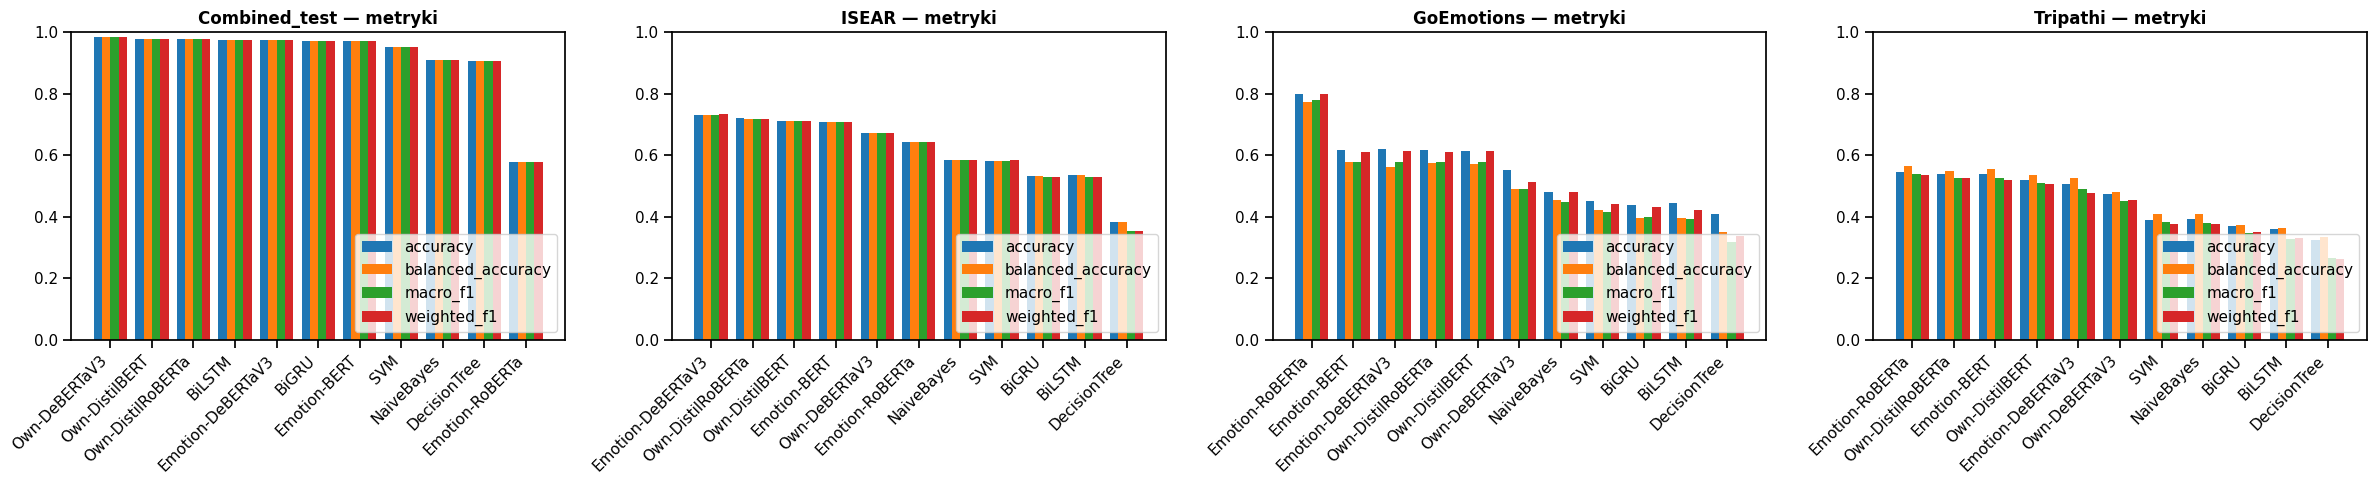

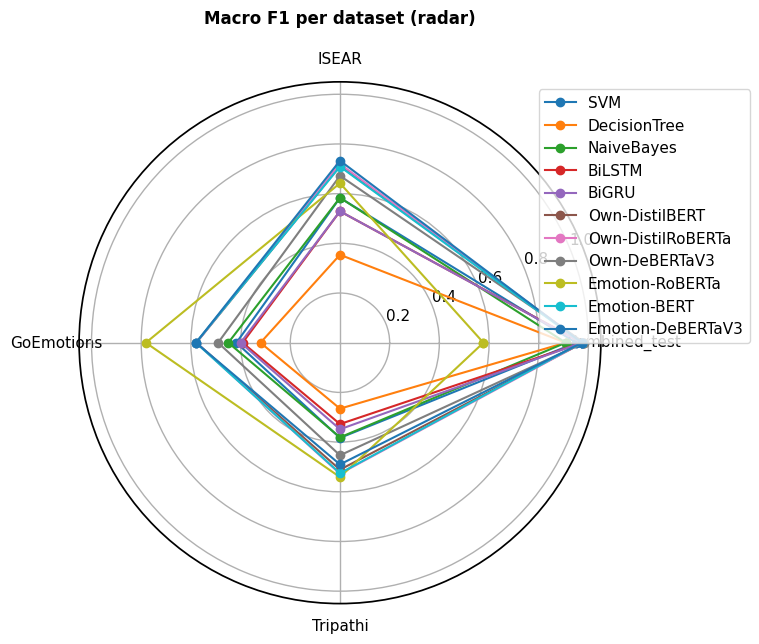

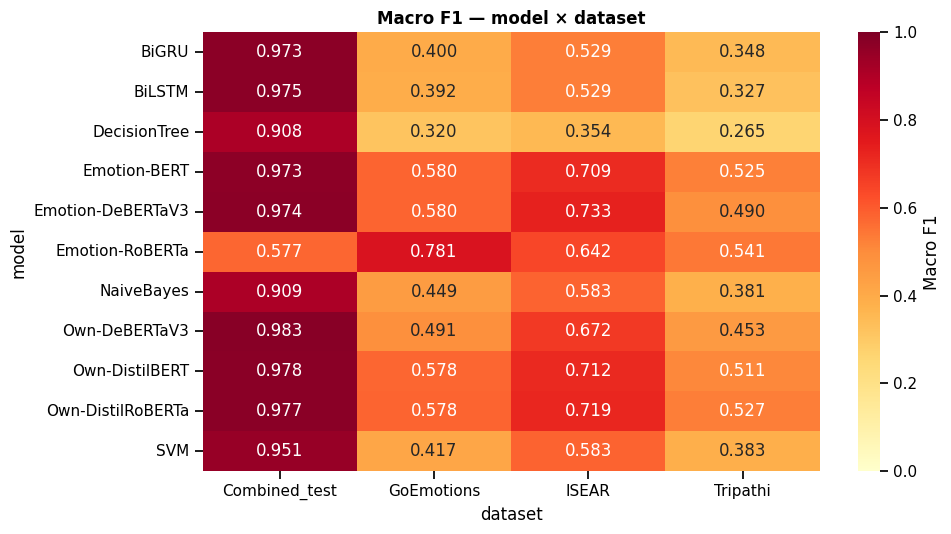


=== Best overall model (avg macro_f1): Own-DistilRoBERTa ===

Own-DistilRoBERTa — Combined_test:
         precision  recall  f1-score
anger       0.9686  0.9673    0.9680
fear        0.9636  0.9893    0.9763
joy         0.9886  0.9827    0.9856
sadness     0.9871  0.9680    0.9774

Own-DistilRoBERTa — ISEAR:
         precision  recall  f1-score
anger       0.5985  0.8173    0.6910
fear        0.7701  0.8032    0.7863
joy         0.8194  0.6972    0.7534
sadness     0.7626  0.5607    0.6463

Own-DistilRoBERTa — GoEmotions:
         precision  recall  f1-score
anger       0.5637  0.7782    0.6538
fear        0.4455  0.4591    0.4522
joy         0.7644  0.6623    0.7097
sadness     0.6510  0.4026    0.4975

Own-DistilRoBERTa — Tripathi:
         precision  recall  f1-score
anger       0.4445  0.7844    0.5674
fear        0.7354  0.3458    0.4704
joy         0.5761  0.7122    0.6370
sadness     0.5478  0.3603    0.4347


In [14]:
if len(results_df) > 0:
    metrics = ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']

    # 1. Grouped bar: models x datasets
    fig, axes = plt.subplots(1, len(EVAL_SETS), figsize=(6*len(EVAL_SETS), 5))
    if len(EVAL_SETS) == 1:
        axes = [axes]
    for ax, (ds_name, _) in zip(axes, EVAL_SETS.items()):
        sub = results_df[results_df['dataset'] == ds_name].sort_values('macro_f1', ascending=False)
        x = np.arange(len(sub))
        w = 0.2
        for i, m in enumerate(metrics):
            ax.bar(x + i*w - 1.5*w, sub[m].values, w, label=m)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['model'].values, rotation=45, ha='right')
        ax.set_title(f'{ds_name} — metryki', fontweight='bold')
        ax.legend(loc='lower right')
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'comparison_grouped.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Radar chart
    from math import pi
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    models_in_plot = results_df['model'].unique()
    datasets_in_plot = list(EVAL_SETS.keys())
    angles = [n / len(datasets_in_plot) * 2 * pi for n in range(len(datasets_in_plot))]
    angles += angles[:1]
    for model_name in models_in_plot:
        vals = []
        for ds in datasets_in_plot:
            row = results_df[(results_df['model'] == model_name) & (results_df['dataset'] == ds)]
            vals.append(row['macro_f1'].values[0] if len(row) > 0 else 0)
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', label=model_name)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(datasets_in_plot)
    ax.set_ylim(0, 1.05)
    ax.set_title('Macro F1 per dataset (radar)', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'comparison_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Heatmap model x dataset
    pivot = results_df.pivot_table(index='model', columns='dataset', values='macro_f1', aggfunc='first')
    plt.figure(figsize=(10, max(5, len(pivot)*0.5)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1, cbar_kws={'label': 'Macro F1'})
    plt.title('Macro F1 — model × dataset', fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'comparison_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 4. Per-class accuracy per dataset (best model)
    best_model = results_df.groupby('model')['macro_f1'].mean().idxmax()
    print(f'\n=== Best overall model (avg macro_f1): {best_model} ===')
    for ds_name, ds_df in EVAL_SETS.items():
        d = all_predictions[best_model][ds_name]
        cr = classification_report(d['y_true'], d['y_pred'], target_names=label_names, zero_division=0, output_dict=True)
        per_class = pd.DataFrame(cr).T
        print(f'\n{best_model} — {ds_name}:')
        print(per_class[['precision', 'recall', 'f1-score']].drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore').round(4))

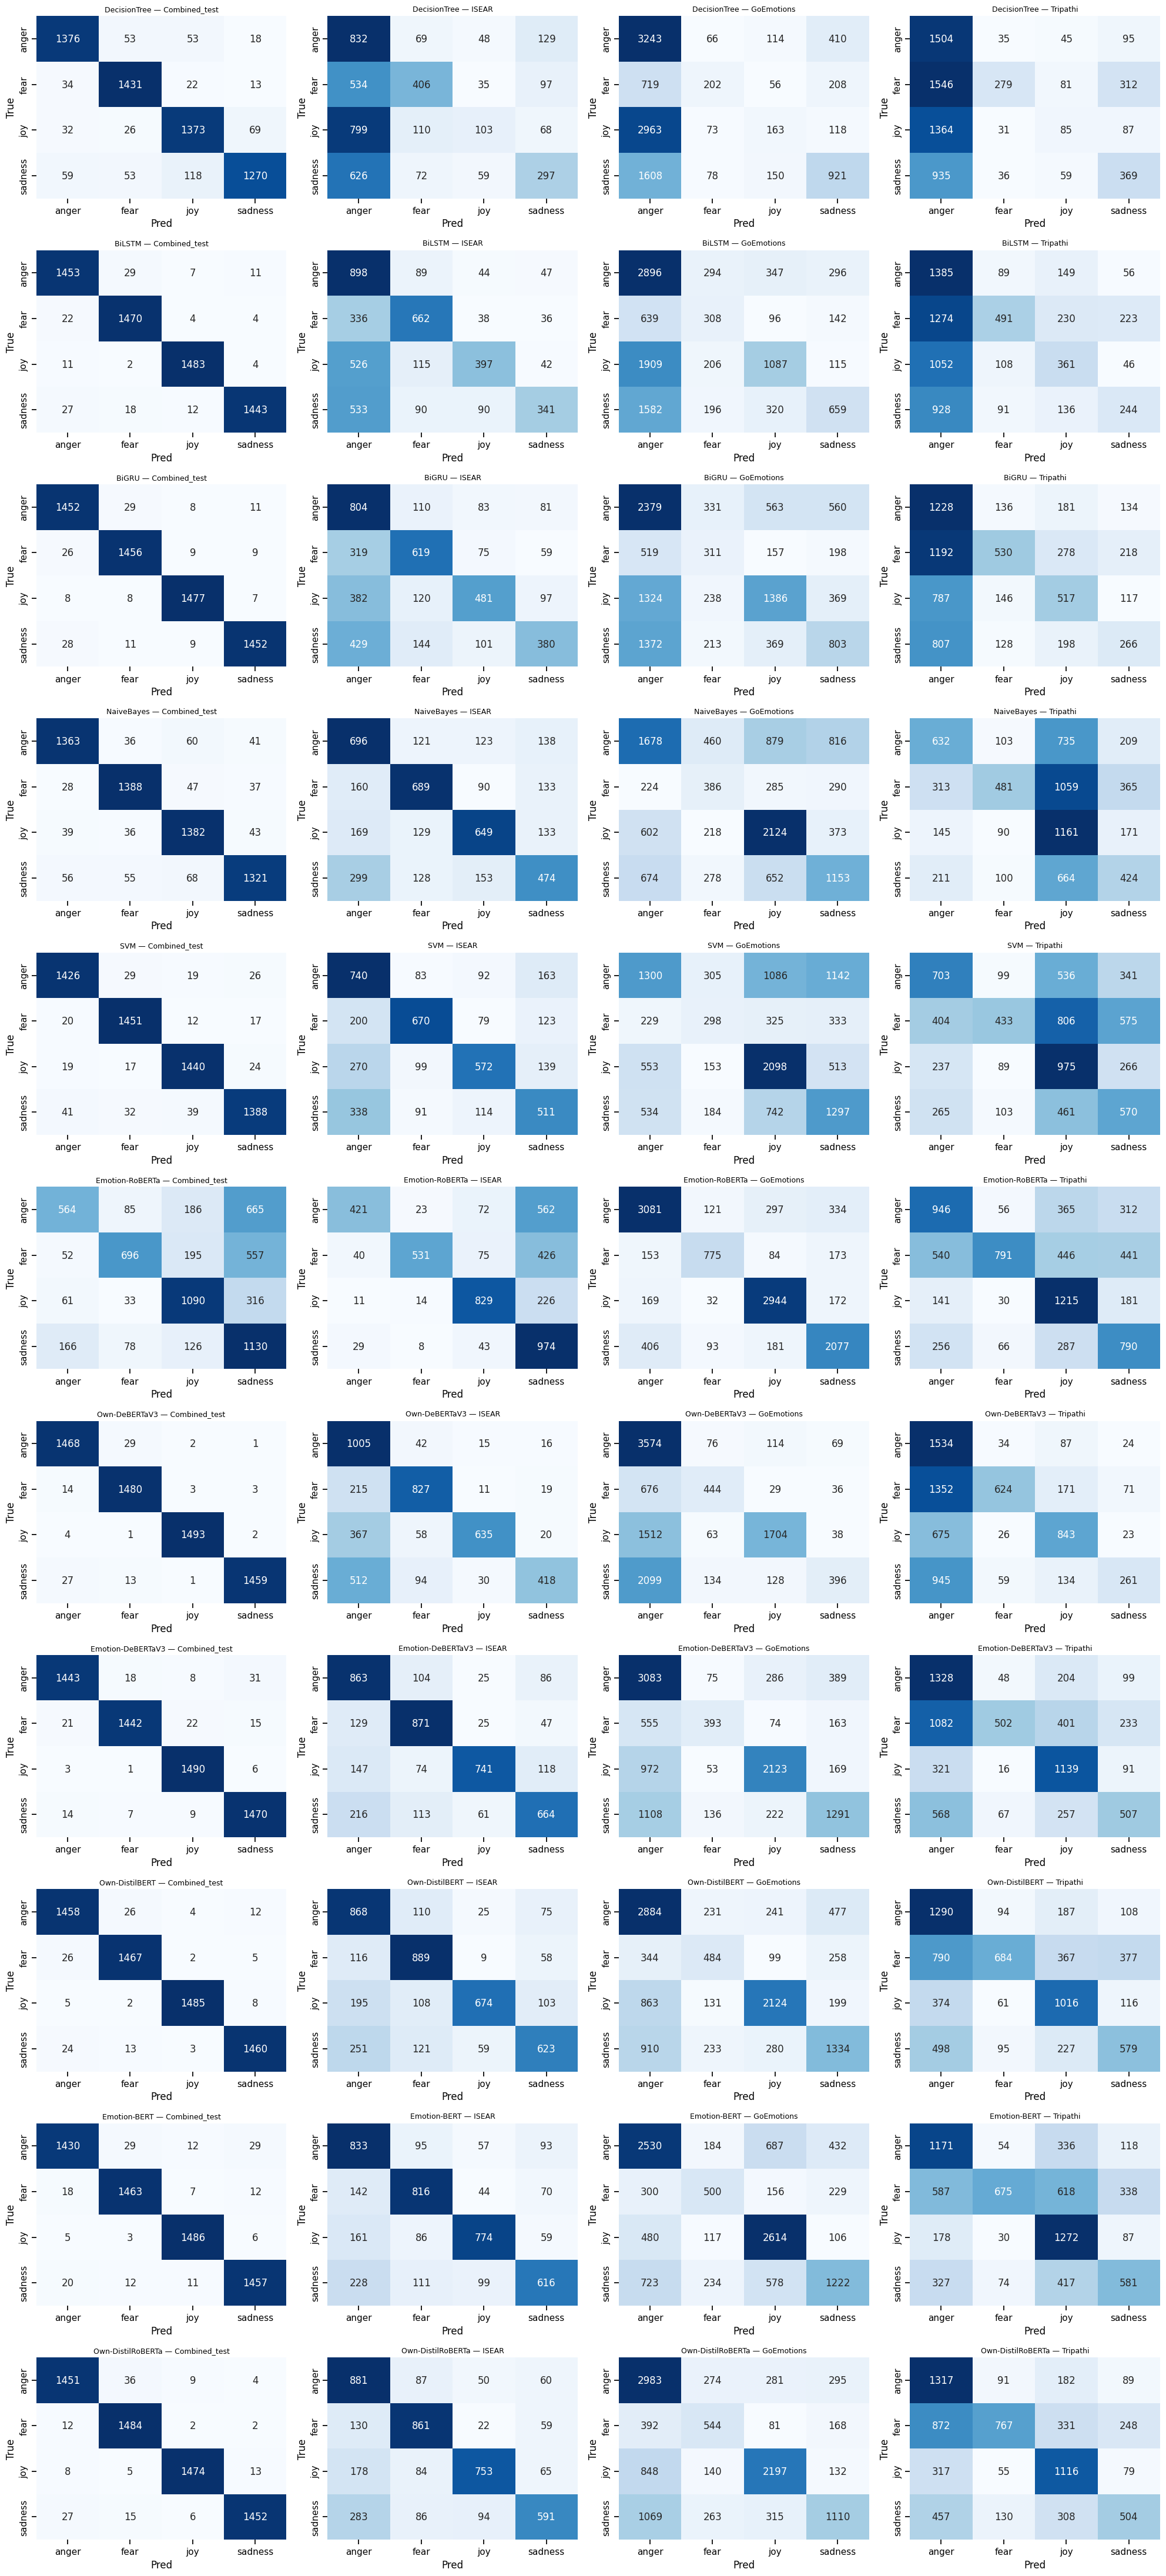

In [15]:
# Confusion matrices grid: rows = models, columns = datasets
model_order = results_df.groupby('model')['macro_f1'].mean().sort_values(ascending=True).index
ds_order = list(EVAL_SETS.keys())
fig, axes = plt.subplots(len(model_order), len(ds_order), figsize=(5*len(ds_order), 4*len(model_order)), squeeze=False)
for i, model_name in enumerate(model_order):
    for j, ds_name in enumerate(ds_order):
        ax = axes[i, j]
        d = all_predictions[model_name][ds_name]
        cm = confusion_matrix(d['y_true'], d['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=ax, cbar=False)
        ax.set_title(f'{model_name} — {ds_name}', fontsize=9)
        ax.set_xlabel('Pred')
        ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix_grid.png', dpi=150)
plt.show()

In [16]:
# Training curves dla transformerów (z logów)
log_files = list(CHECKPOINT_DIR.glob('hf_*/trainer_state.json'))
if log_files:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for log_f in log_files:
        with open(log_f) as f:
            state = json.load(f)
        logs = state.get('log_history', [])
        name = log_f.parent.name.replace('hf_', '')
        train_loss = [l['loss'] for l in logs if 'loss' in l]
        eval_f1 = [l['eval_macro_f1'] for l in logs if 'eval_macro_f1' in l]
        if train_loss:
            axes[0].plot(train_loss, label=name)
        if eval_f1:
            axes[1].plot(eval_f1, label=name, marker='o')
    axes[0].set_title('Training loss')
    axes[0].legend(); axes[1].legend()
    axes[1].set_title('Validation macro F1')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'training_curves.png', dpi=150)
    plt.show()

---

## Eksperyment 4 — XAI: Wyjaśnialność predykcji

**Pytanie badawcze:** Na jakich słowach opierają się modele podejmując decyzję? Czy różne architektury zwracają uwagę na te same fragmenty tekstu?

**Metody:**
- **LIME** (Local Interpretable Model-agnostic Explanations) — dla modeli klasycznych i transformerów. Generuje lokalne liniowe przybliżenia modelu przez losowe perturbacje tekstu.
- **Integrated Gradients** — dla sieci rekurencyjnych (BiLSTM, BiGRU). Mierzy jak bardzo zmiana embeddingu każdego tokenu wpływa na wyjście modelu.

**Analiza zgodności XAI:**  
Po wygenerowaniu wyjaśnień dla wszystkich modeli porównujemy je pod kątem zgodności — czy wskazują na te same słowa kluczowe? Metryki: Jaccard (top-k tokenów), Spearman (rangi), cosine similarity (wektory atrybucji).

> Wysoka zgodność między różnymi metodami XAI zwiększa zaufanie do wyjaśnień.

---


  LIME skipped for SVM (no predict_proba)


LIME DecisionTree: 100%|████████████████████████████████████████████████████████████████| 30/30 [00:08<00:00,  3.38it/s]


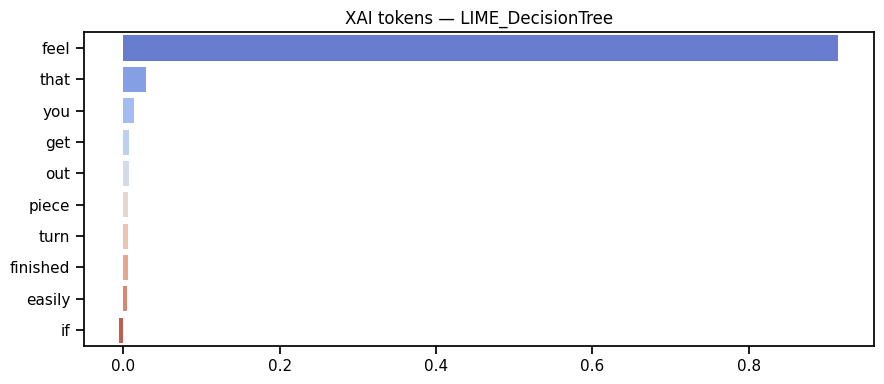

LIME NaiveBayes: 100%|██████████████████████████████████████████████████████████████████| 30/30 [00:08<00:00,  3.43it/s]


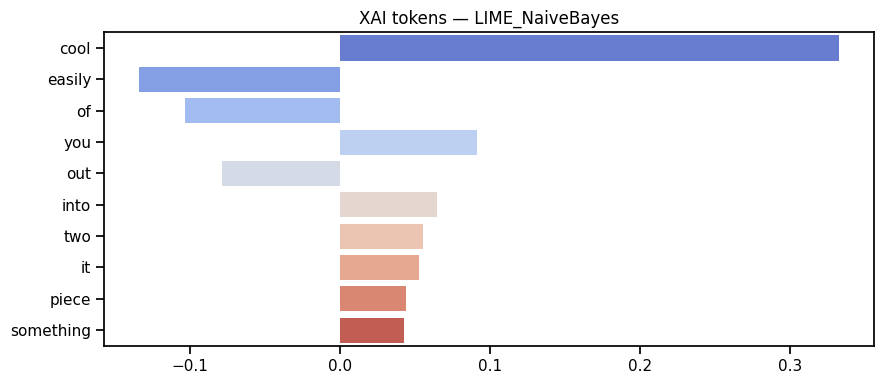

IG BiLSTM: 100%|████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 32.92it/s]


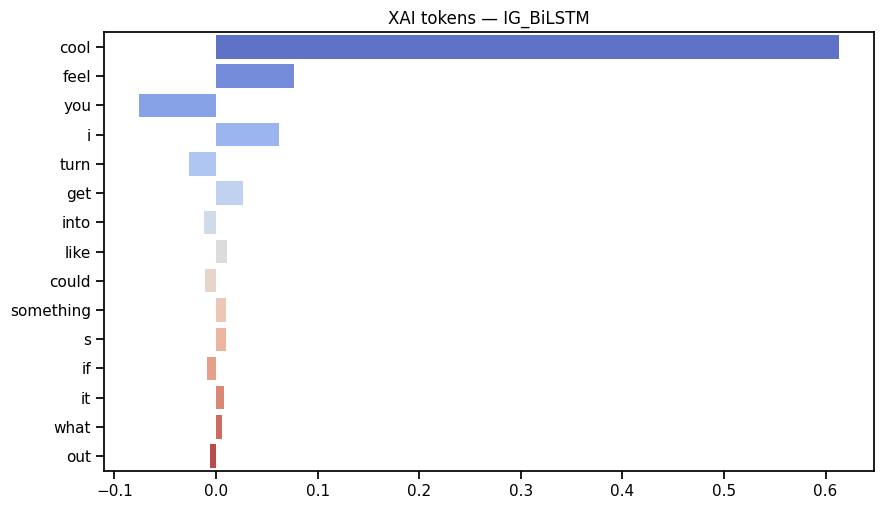

IG BiGRU: 100%|█████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 49.84it/s]


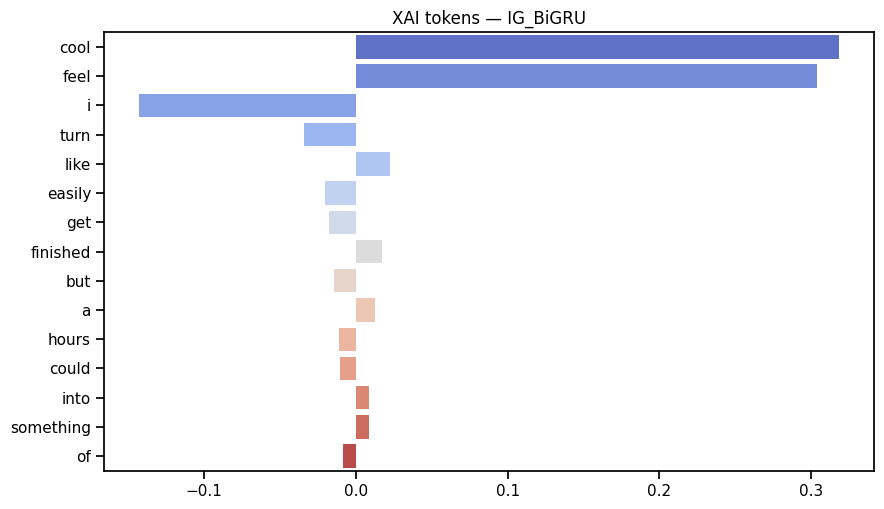

LIME Own-DistilBERT: 100%|██████████████████████████████████████████████████████████████| 30/30 [02:04<00:00,  4.14s/it]


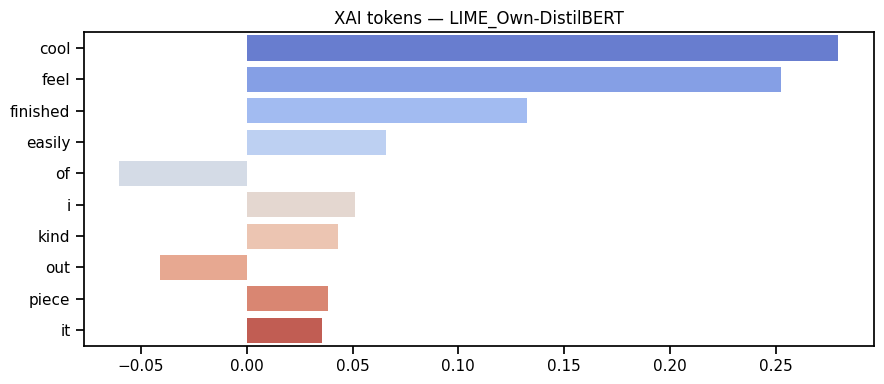

LIME Own-DistilRoBERTa: 100%|███████████████████████████████████████████████████████████| 30/30 [02:11<00:00,  4.38s/it]


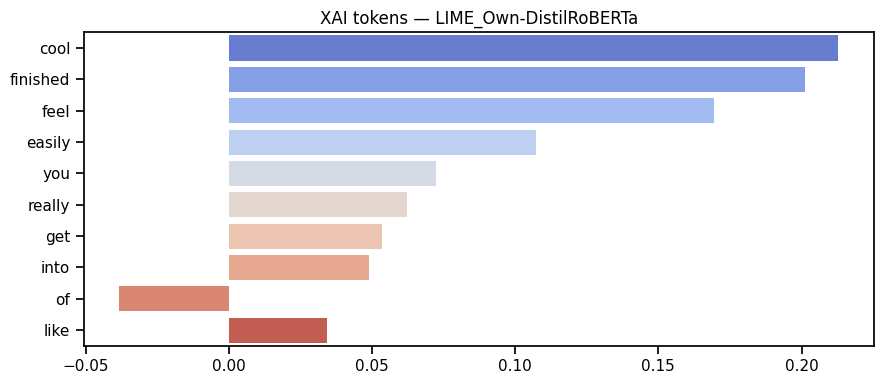

LIME Own-DeBERTaV3: 100%|███████████████████████████████████████████████████████████████| 30/30 [07:22<00:00, 14.76s/it]


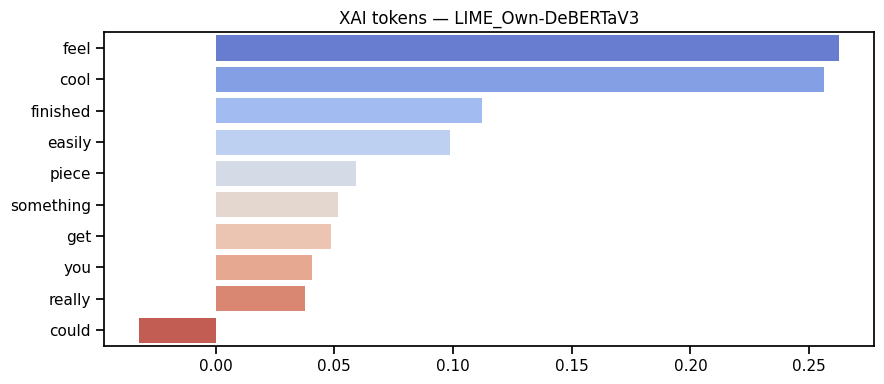

,method_a,method_b,n,jaccard,spearman,cosine
19,LIME_Own-DeBERTaV3,LIME_Own-DistilRoBERTa,30,0.700944,0.577026,0.866675
20,LIME_Own-DistilBERT,LIME_Own-DistilRoBERTa,30,0.695965,0.605185,0.937848
0,IG_BiGRU,IG_BiLSTM,30,0.692892,0.525201,0.839950
18,LIME_Own-DeBERTaV3,LIME_Own-DistilBERT,30,0.687073,0.604700,0.872390
6,IG_BiLSTM,LIME_DecisionTree,30,0.671229,0.171017,0.687340
9,IG_BiLSTM,LIME_Own-DistilBERT,30,0.670568,0.269325,0.713691
11,LIME_DecisionTree,LIME_NaiveBayes,30,0.665188,0.162894,0.692934
17,LIME_NaiveBayes,LIME_Own-DistilRoBERTa,30,0.664948,0.322545,0.790986
14,LIME_DecisionTree,LIME_Own-DistilRoBERTa,30,0.654786,0.279914,0.771771
15,LIME_NaiveBayes,LIME_Own-DeBERTaV3,30,0.653139,0.251681,0.694974


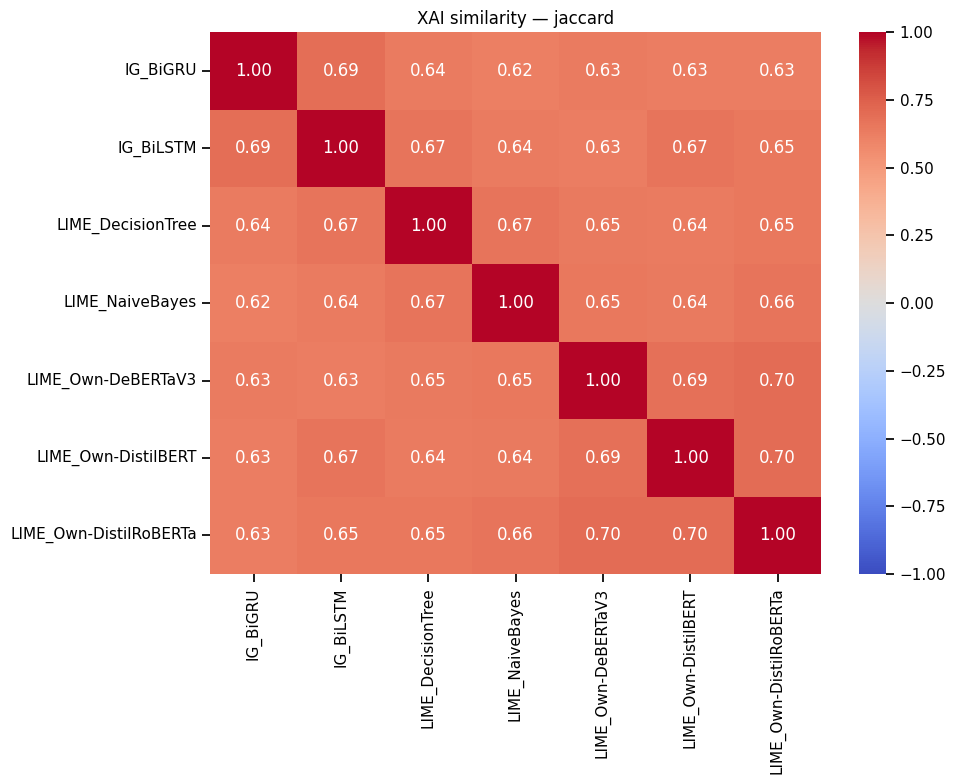

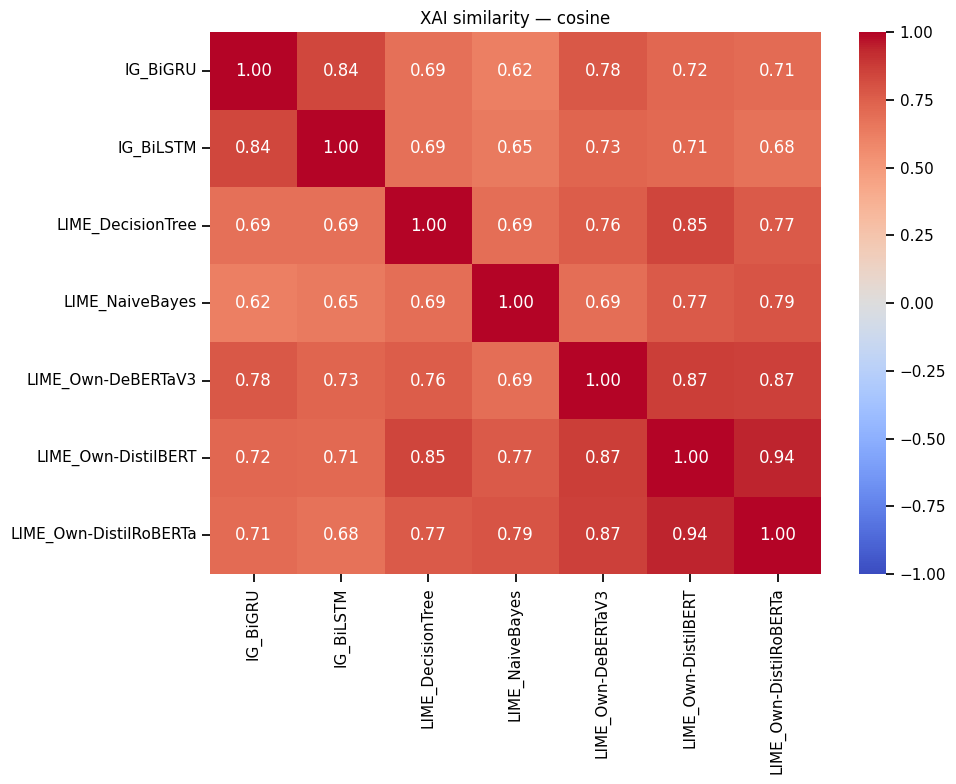

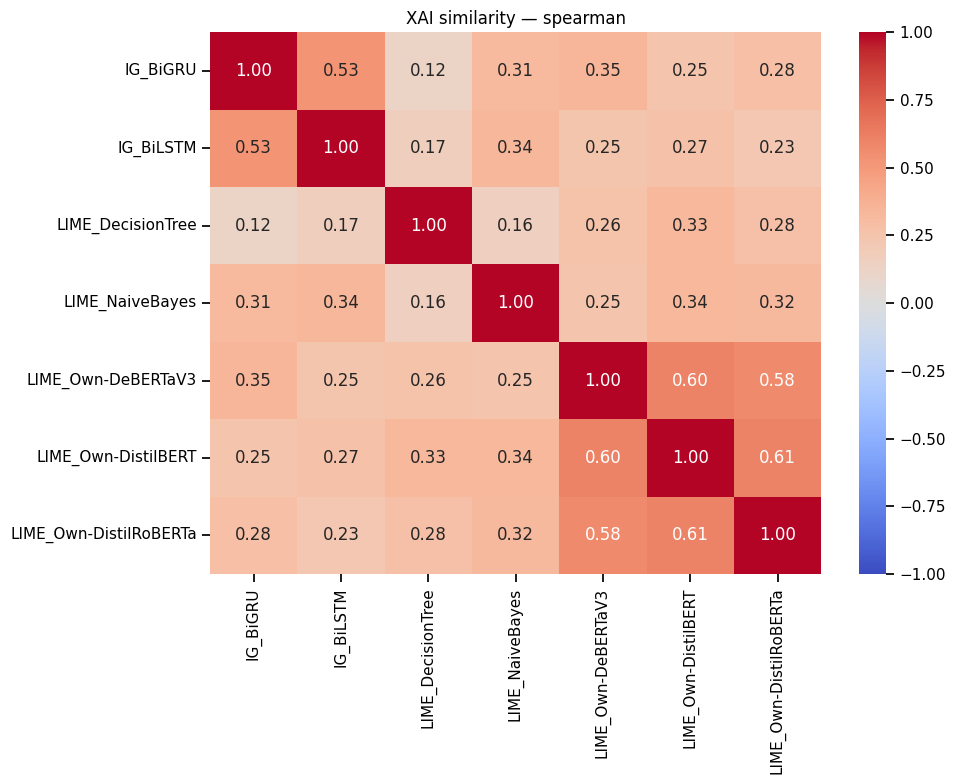

In [17]:
xai_explanations = defaultdict(dict)

sample_xai_df = test_df.sample(min(CONFIG['xai_n_examples'], len(test_df)), random_state=SEED).reset_index(drop=True)

def normalize_attr_dict(d):
    total = sum(abs(v) for v in d.values())
    if total == 0: return d
    return {k: float(v) / total for k, v in d.items()}

def top_tokens_plot(model_name, attr_dict, suffix, top_k=15):
    items = sorted(attr_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:top_k]
    if not items: return
    toks, vals = zip(*items)
    plt.figure(figsize=(9, max(4, 0.35*len(toks))))
    sns.barplot(x=list(vals), y=list(toks), orient='h', palette='coolwarm')
    plt.title(f'XAI tokens — {model_name}')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'xai_{model_name}_{suffix}.png', dpi=150)
    plt.show()

# --- LIME dla modeli klasycznych ---
try:
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
except:
    LIME_AVAILABLE = False

if LIME_AVAILABLE and len(classic_fns) > 0:
    explainer = LimeTextExplainer(class_names=label_names)
    for name, predict_fn in classic_fns.items():
        _, proba_check = predict_fn([sample_xai_df.iloc[0]['text']])
        if proba_check is None:
            print(f'  LIME skipped for {name} (no predict_proba)')
            continue
        def make_proba_fn(pfn):
            def proba_fn(texts):
                _, p = pfn(texts)
                if np.isnan(p).any():
                    p = np.full_like(p, 1.0 / p.shape[1])
                return p
            return proba_fn
        pfn = make_proba_fn(predict_fn)
        for i, row in tqdm(sample_xai_df.iterrows(), total=len(sample_xai_df), desc=f'LIME {name}'):
            exp = explainer.explain_instance(row['text'], pfn, num_features=CONFIG['xai_top_k'], top_labels=1)
            pred_label = exp.available_labels()[0]
            attr = dict(exp.as_list(label=pred_label))
            xai_explanations[f'LIME_{name}'][i] = normalize_attr_dict(attr)
        if len(sample_xai_df):
            top_tokens_plot(f'LIME_{name}', xai_explanations[f'LIME_{name}'][0], 'sample0')

# --- Integrated Gradients dla RNN ---
try:
    from captum.attr import LayerIntegratedGradients
    CAPTUM_AVAILABLE = True
except:
    CAPTUM_AVAILABLE = False

if CAPTUM_AVAILABLE:
    for name, predict_fn in rnn_fns.items():
        ckpt = torch.load(CHECKPOINT_DIR / f'{name}.pt', map_location=DEVICE, weights_only=False)
        vocab = ckpt['vocab']
        model = BiRNNClassifier(len(vocab.itos), CONFIG['embed_dim'], CONFIG['hidden_dim'], num_labels, rnn_type='lstm' if 'LSTM' in name else 'gru').to(DEVICE)
        model.load_state_dict(ckpt['model_state'])
        model.eval()

        for i, row in tqdm(sample_xai_df.iterrows(), total=len(sample_xai_df), desc=f'IG {name}'):
            ids = torch.tensor([vocab.encode(row['text'], CONFIG['max_seq_len_rnn'])], dtype=torch.long).to(DEVICE)
            tokens = [vocab.itos[j] if j < len(vocab.itos) else '<unk>' for j in ids[0].cpu().numpy()]
            lig = LayerIntegratedGradients(lambda x: model(x), model.embedding)
            baseline = torch.zeros_like(ids).to(DEVICE)
            model.train()
            attributions, _ = lig.attribute(ids, baselines=baseline, target=int(row['label']), return_convergence_delta=True)
            model.eval()
            scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
            attr = defaultdict(float)
            for tok, score in zip(tokens, scores):
                if tok not in ['<pad>', '<unk>']:
                    attr[tok] += float(score)
            xai_explanations[f'IG_{name}'][i] = normalize_attr_dict(dict(attr))
        if len(sample_xai_df):
            top_tokens_plot(f'IG_{name}', xai_explanations[f'IG_{name}'][0], 'sample0')

# --- LIME dla transformerów ---
if LIME_AVAILABLE and len(hf_predict_fns) > 0:
    explainer = LimeTextExplainer(class_names=label_names)
    for name, predict_fn in hf_predict_fns.items():
        def make_proba_fn(pfn):
            def proba_fn(texts):
                _, p = pfn(texts)
                if np.isnan(p).any():
                    p = np.full_like(p, 1.0 / p.shape[1])
                return p
            return proba_fn
        pfn = make_proba_fn(predict_fn)
        for i, row in tqdm(sample_xai_df.iterrows(), total=len(sample_xai_df), desc=f'LIME {name}'):
            try:
                exp = explainer.explain_instance(row['text'], pfn, num_features=CONFIG['xai_top_k'], top_labels=1)
                pred_label = exp.available_labels()[0]
                xai_explanations[f'LIME_{name}'][i] = normalize_attr_dict(dict(exp.as_list(label=pred_label)))
            except (ValueError, RuntimeError) as e:
                print(f'  XAI skipped for {name} sample {i}: {e}')
                continue
        if len(sample_xai_df) and f'LIME_{name}' in xai_explanations and 0 in xai_explanations[f'LIME_{name}']:
            top_tokens_plot(f'LIME_{name}', xai_explanations[f'LIME_{name}'][0], 'sample0')

# --- Similarity XAI ---
if len(xai_explanations) > 1:
    from sklearn.metrics.pairwise import cosine_similarity
    from scipy.stats import spearmanr

    def jaccard_top_k(a, b, k=10):
        ta = set(x for x, _ in sorted(a.items(), key=lambda z: abs(z[1]), reverse=True)[:k])
        tb = set(x for x, _ in sorted(b.items(), key=lambda z: abs(z[1]), reverse=True)[:k])
        if not ta and not tb: return np.nan
        return len(ta & tb) / len(ta | tb)

    def attr_sim(a, b, k=10):
        keys = sorted(set(a) | set(b))
        va = np.array([a.get(kk, 0.0) for kk in keys])
        vb = np.array([b.get(kk, 0.0) for kk in keys])
        if len(keys) == 0:
            return {'jaccard': np.nan, 'spearman': np.nan, 'cosine': np.nan}
        cos = cosine_similarity([va], [vb])[0,0] if np.linalg.norm(va) > 0 and np.linalg.norm(vb) > 0 else np.nan
        sp = spearmanr(va, vb).correlation if len(keys) > 1 else np.nan
        return {'jaccard': jaccard_top_k(a, b, k), 'spearman': sp, 'cosine': cos}

    rows = []
    methods = sorted(xai_explanations.keys())
    for m1_i, m1 in enumerate(methods):
        for m2 in methods[m1_i+1:]:
            common = sorted(set(xai_explanations[m1]) & set(xai_explanations[m2]))
            if not common: continue
            sims = [attr_sim(xai_explanations[m1][i], xai_explanations[m2][i], CONFIG['xai_top_k']) for i in common]
            row = {'method_a': m1, 'method_b': m2, 'n': len(common)}
            for metric in sims[0]:
                row[metric] = np.nanmean([s[metric] for s in sims])
            rows.append(row)

    xai_sim_df = pd.DataFrame(rows)
    xai_sim_df.to_csv(REPORTS_DIR / 'xai_similarity.csv', index=False)
    display(xai_sim_df.sort_values('jaccard', ascending=False).head(20))

    for metric in ['jaccard', 'cosine', 'spearman']:
        pivot = pd.DataFrame(index=sorted(xai_explanations.keys()), columns=sorted(xai_explanations.keys()), dtype=float)
        np.fill_diagonal(pivot.values, 1.0)
        for _, r in xai_sim_df.iterrows():
            pivot.loc[r['method_a'], r['method_b']] = r[metric]
            pivot.loc[r['method_b'], r['method_a']] = r[metric]
        plt.figure(figsize=(10, 8))
        sns.heatmap(pivot.astype(float), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
        plt.title(f'XAI similarity — {metric}')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f'xai_sim_{metric}.png', dpi=150)
        plt.show()

---

## Eksperyment 6 — Analiza błędnych klasyfikacji

**Pytanie badawcze:** Czy istnieją próbki, które **wszystkie** najlepsze modele klasyfikują błędnie? Jeśli tak — dlaczego?

**Metoda:**  
Dla każdego zbioru testowego znajdujemy przykłady błędnie sklasyfikowane przez wszystkie najlepsze modele jednocześnie (AND warunków błędu). Takie próbki są „najtwardszymi" przypadkami — trudnymi fundamentalnie, a nie tylko dla jednej architektury.

**Co szukamy:**
- Teksty z niejednoznaczną emocją (np. "I cried watching the sunset" — smutek czy radość?)
- Krótkie, kontekstowo ubogie zdania
- Idiomy i wyrażenia figuratywne
- Wzorce mieszanych emocji

---


In [18]:
if len(all_results) > 0:
    # Znajdź najlepsze modele (DistilBERT, DistilRoBERTa i pretrained)
    top_models = [m for m in ['Own-DistilBERT', 'Own-DistilRoBERTa', 'Emotion-RoBERTa', 'Emotion-BERT', 'Emotion-DeBERTaV3', 'Own-DeBERTaV3']
                 if m in all_predictions and 'Combined_test' in all_predictions[m]]
    
    print(f'Top models for misanalysis: {top_models}')
    
    for ds_name in ['Combined_test', 'ISEAR', 'GoEmotions']:
        if ds_name not in EVAL_SETS:
            continue
        df = EVAL_SETS[ds_name]
        
        # Znajdź indeksy gdzie WSZYSTKIE top modele się mylą
        wrong_mask = None
        for m in top_models:
            if ds_name in all_predictions[m]:
                w = all_predictions[m][ds_name]['y_true'] != all_predictions[m][ds_name]['y_pred']
                if wrong_mask is None:
                    wrong_mask = w.copy()
                else:
                    wrong_mask = wrong_mask & w
        
        if wrong_mask is not None and wrong_mask.sum() > 0:
            wrong_indices = np.where(wrong_mask)[0]
            print(f'\n=== {ds_name}: {len(wrong_indices)} próbek błędnych we WSZYSTKICH top modelach ===')
            
            for idx in wrong_indices[:10]:  # top 10
                text = df.iloc[idx]['text']
                true_em = df.iloc[idx]['emotion']
                print(f'\nTekst: {text[:120]}...' if len(text) > 120 else f'\nTekst: {text}')
                print(f'  Prawdziwa emocja: {true_em}')
                for m in top_models:
                    if ds_name in all_predictions[m]:
                        pred = all_predictions[m][ds_name]['y_pred'][idx]
                        proba = all_predictions[m][ds_name]['y_proba'][idx] if all_predictions[m][ds_name]['y_proba'] is not None else None
                        pred_em = label_names[pred]
                        conf = proba[pred] if proba is not None else 0
                        marker = ' X' if true_em != pred_em else ' OK'
                        print(f'  {m:25s} -> {pred_em:12s} (conf={conf:.3f}){marker}')
        else:
            print(f'\n=== {ds_name}: brak próbek błędnych we wszystkich modelach jednocześnie ===')


Top models for misanalysis: ['Own-DistilBERT', 'Own-DistilRoBERTa', 'Emotion-RoBERTa', 'Emotion-BERT', 'Emotion-DeBERTaV3', 'Own-DeBERTaV3']

=== Combined_test: 17 próbek błędnych we WSZYSTKICH top modelach ===

Tekst: i feel agitated yet exhausted yearning for social reconnections yet timid and recluse
  Prawdziwa emocja: anger
  Own-DistilBERT            -> fear         (conf=0.613) X
  Own-DistilRoBERTa         -> fear         (conf=0.835) X
  Emotion-RoBERTa           -> sadness      (conf=0.804) X
  Emotion-BERT              -> fear         (conf=0.940) X
  Emotion-DeBERTaV3         -> fear         (conf=0.694) X
  Own-DeBERTaV3             -> fear         (conf=0.832) X

Tekst: i love the keyboard i love the feel of the device itself but i hated windows mobile
  Prawdziwa emocja: sadness
  Own-DistilBERT            -> anger        (conf=0.998) X
  Own-DistilRoBERTa         -> anger        (conf=0.951) X
  Emotion-RoBERTa           -> anger        (conf=0.740) X
  Emotion-BERT    

---

## Eksperyment 7 — Wpływ długości tekstu na skuteczność

**Pytanie badawcze:** Czy krótkie lub długie teksty są trudniejsze do klasyfikacji?

**Hipotezy:**
- Krótkie teksty (< 5 słów) mogą być trudne — zbyt mało kontekstu
- Długie teksty mogą sprawiać trudność modelom z ograniczeniem długości sekwencji (np. transformery z `max_len=64`)

**Metoda:**  
Podział próbek testowych na przedziały długości (0–5, 5–10, ..., 100+ słów) i pomiar procentu błędnych klasyfikacji w każdym przedziale. Test statystyczny Manna-Whitneya sprawdza czy różnica między długościami poprawnych i błędnych próbek jest istotna statystycznie.

---



Dataset: Combined_test


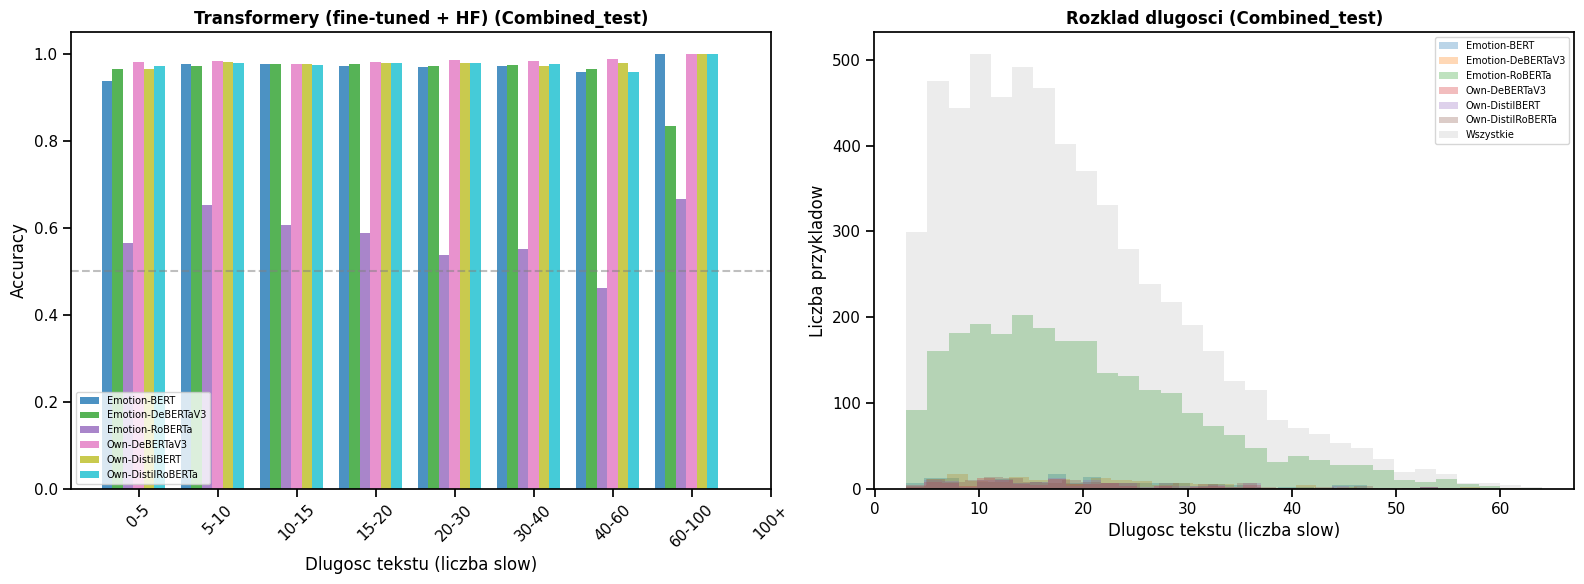

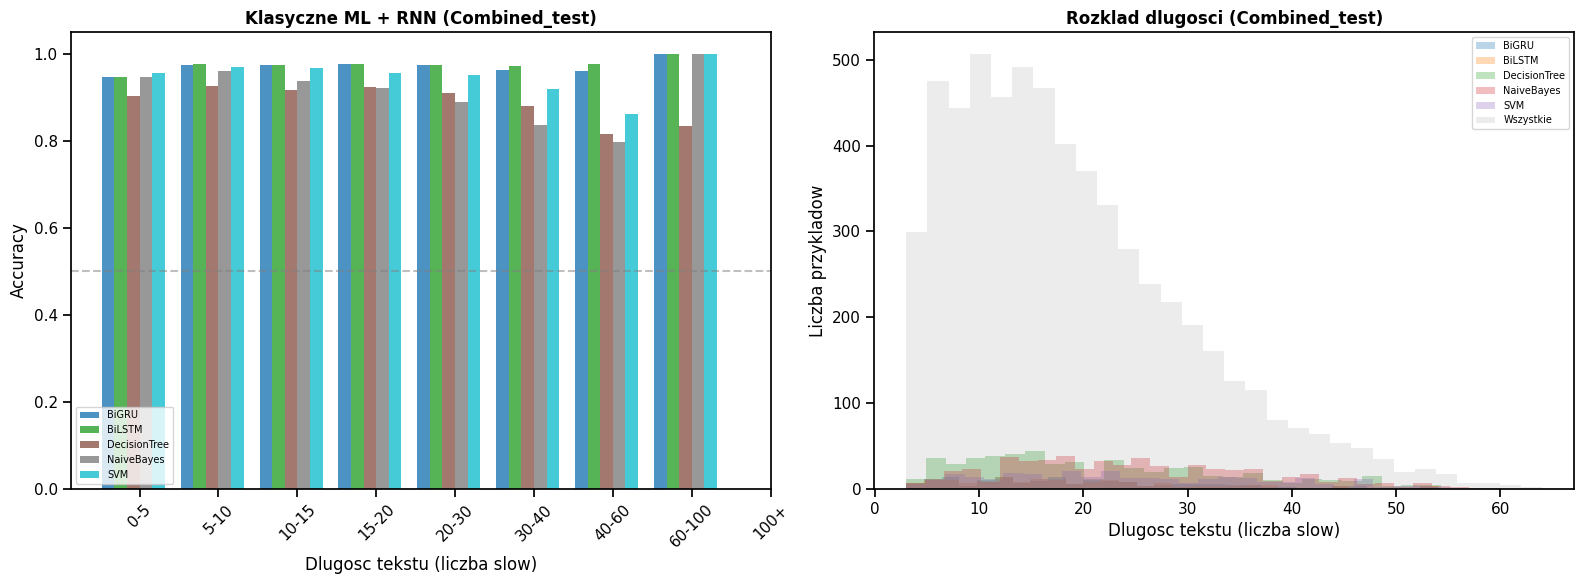


Procent blednych klasyfikacji per przedzial (Combined_test):


,dlugosc,n,BiGRU,BiLSTM,DecisionTree,Emotion-BERT,Emotion-DeBERTaV3,Emotion-RoBERTa,NaiveBayes,Own-DeBERTaV3,Own-DistilBERT,Own-DistilRoBERTa,SVM
0,0-5,113,5.3,5.3,9.7,6.2,3.5,43.4,5.3,1.8,3.5,2.7,4.4
1,5-10,1105,2.4,2.4,7.3,2.3,2.8,34.8,3.8,1.6,1.9,2.1,3.0
2,10-15,1196,2.6,2.6,8.2,2.2,2.3,39.3,6.2,2.3,2.3,2.6,3.1
3,15-20,1129,2.4,2.3,7.6,2.7,2.2,41.1,7.7,1.8,2.0,2.1,4.3
4,20-30,1437,2.4,2.5,9.0,3.0,2.6,46.3,11.0,1.3,2.1,1.9,4.9
5,30-40,672,3.6,2.7,12.1,2.7,2.5,44.8,16.4,1.5,2.7,2.4,8.0
6,40-60,342,3.8,2.3,18.4,4.1,3.5,53.8,20.2,1.2,2.0,4.1,13.7
7,60-100,6,0.0,0.0,16.7,0.0,16.7,33.3,0.0,0.0,0.0,0.0,0.0


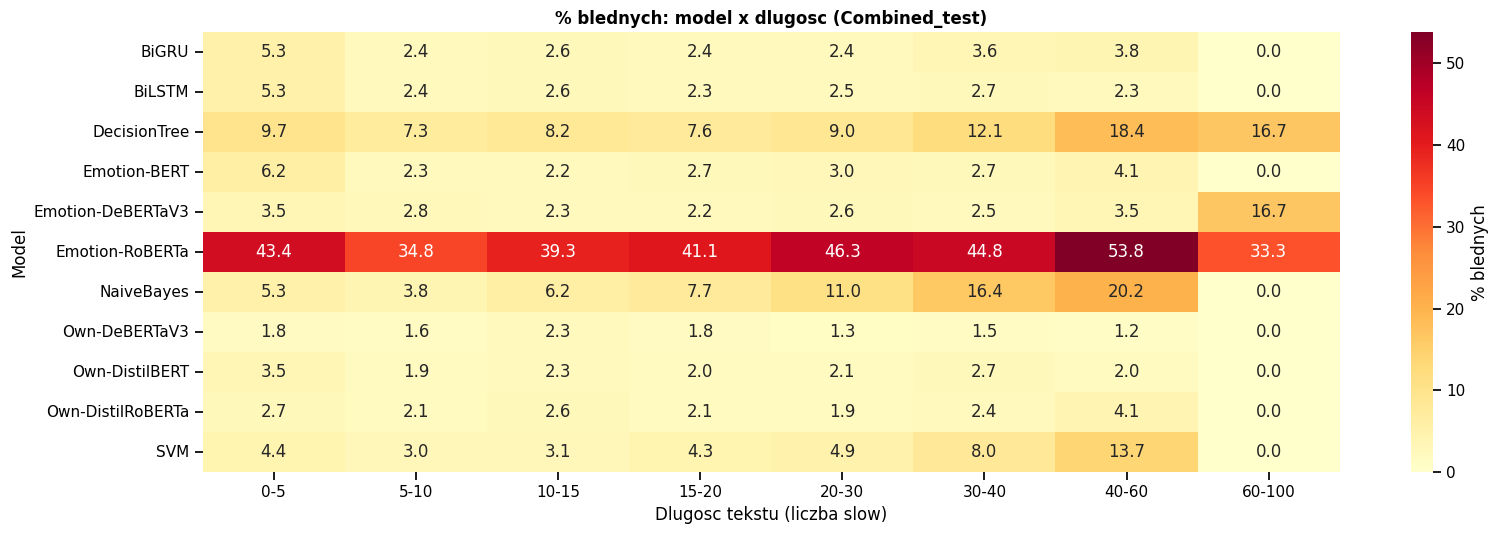


Test Manna-Whitneya (Combined_test):
  BiGRU                     popr=19.07 slow | bledne=20.09 slow | p=0.363412
  BiLSTM                    popr=19.09 slow | bledne=19.25 slow | p=0.998727
  DecisionTree              popr=18.83 slow | bledne=21.79 slow | p=0.000001
  Emotion-BERT              popr=19.07 slow | bledne=20.24 slow | p=0.205969
  Emotion-DeBERTaV3         popr=19.08 slow | bledne=19.75 slow | p=0.695181
  Emotion-RoBERTa           popr=18.23 slow | bledne=20.30 slow | p=0.000000
  NaiveBayes                popr=18.54 slow | bledne=24.63 slow | p=0.000000
  Own-DeBERTaV3             popr=19.12 slow | bledne=17.85 slow | p=0.254995
  Own-DistilBERT            popr=19.09 slow | bledne=19.45 slow | p=0.749627
  Own-DistilRoBERTa         popr=19.07 slow | bledne=20.43 slow | p=0.489416
  SVM                       popr=18.82 slow | bledne=24.48 slow | p=0.000000

Dataset: ISEAR


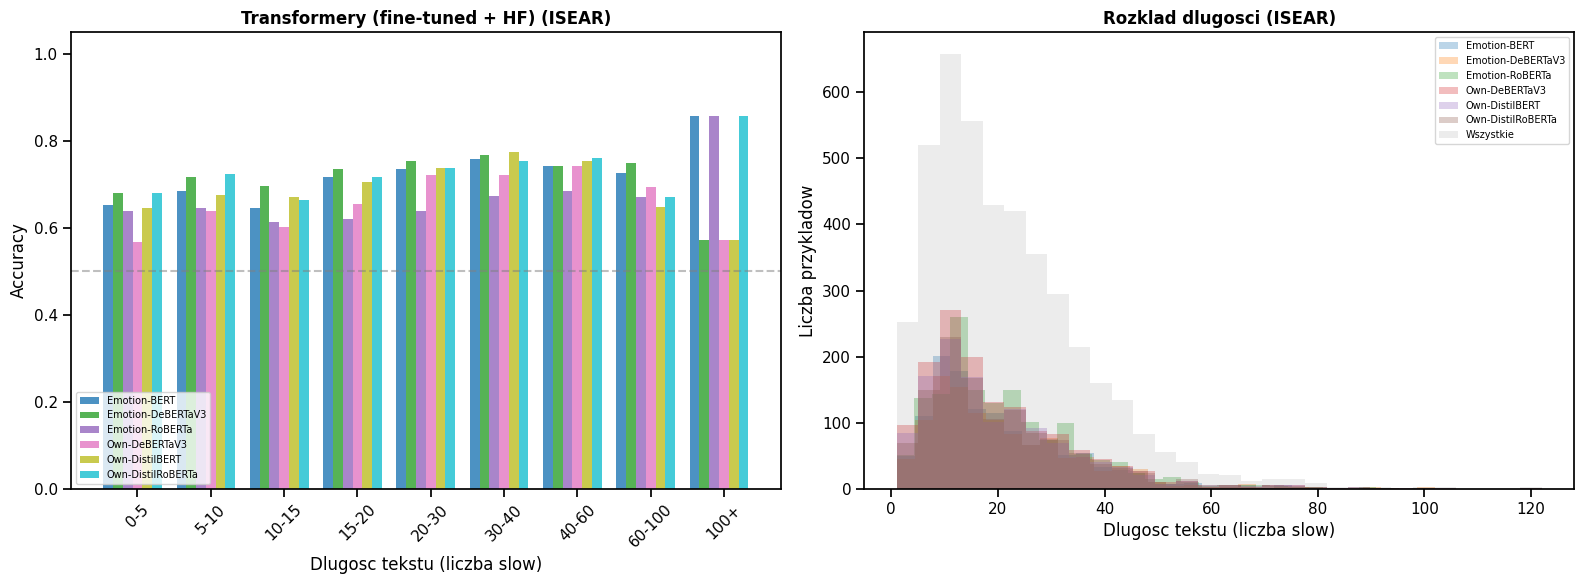

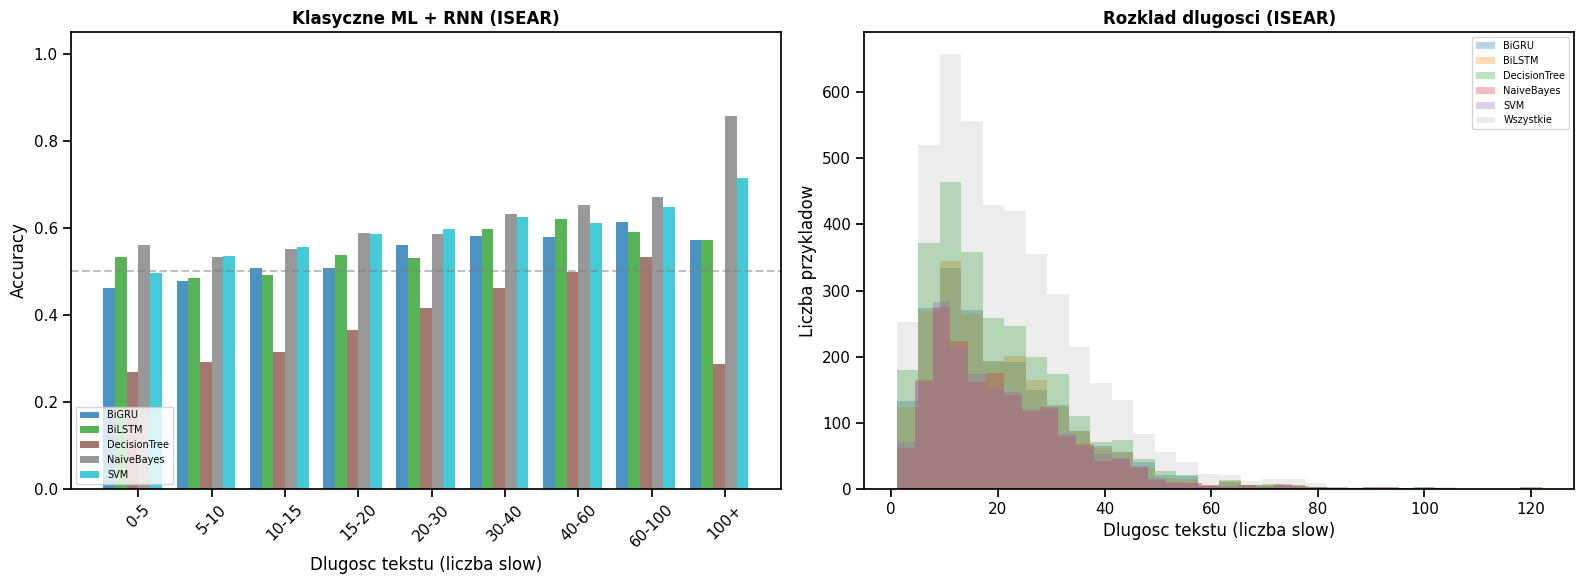


Procent blednych klasyfikacji per przedzial (ISEAR):


,dlugosc,n,BiGRU,BiLSTM,DecisionTree,Emotion-BERT,Emotion-DeBERTaV3,Emotion-RoBERTa,NaiveBayes,Own-DeBERTaV3,Own-DistilBERT,Own-DistilRoBERTa,SVM
0,0-5,141,53.9,46.8,73.0,34.8,31.9,36.2,44.0,43.3,35.5,31.9,50.4
1,5-10,633,52.1,51.5,70.8,31.4,28.3,35.4,46.8,36.0,32.4,27.5,46.4
2,10-15,819,49.2,50.8,68.5,35.4,30.4,38.6,44.9,39.7,32.8,33.6,44.3
3,15-20,613,49.3,46.3,63.5,28.4,26.4,37.8,41.3,34.4,29.5,28.4,41.4
4,20-30,988,44.0,47.0,58.5,26.4,24.7,36.0,41.5,27.9,26.2,26.1,40.3
5,30-40,591,41.8,40.3,53.8,24.2,23.2,32.7,36.7,27.7,22.5,24.5,37.4
6,40-60,404,42.1,37.9,50.2,25.7,25.7,31.4,34.7,25.7,24.5,24.0,38.9
7,60-100,88,38.6,40.9,46.6,27.3,25.0,33.0,33.0,30.7,35.2,33.0,35.2
8,100+,7,42.9,42.9,71.4,14.3,42.9,14.3,14.3,42.9,42.9,14.3,28.6


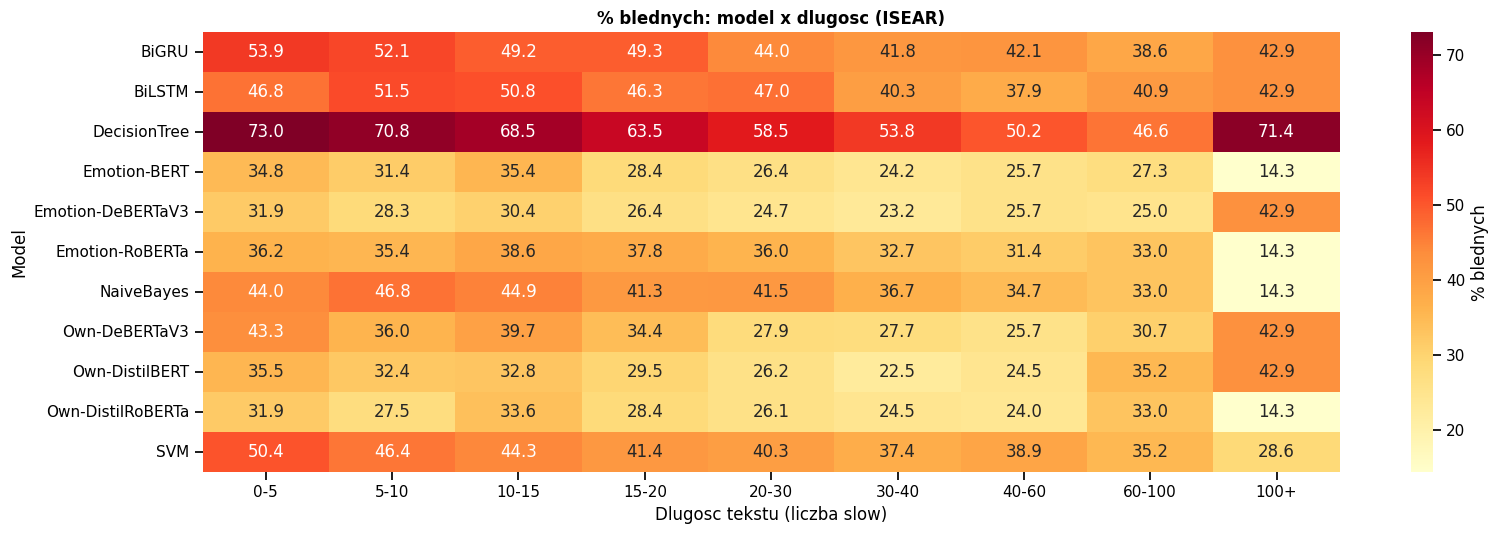


Test Manna-Whitneya (ISEAR):
  BiGRU                     popr=23.16 slow | bledne=20.98 slow | p=0.000000
  BiLSTM                    popr=23.25 slow | bledne=20.85 slow | p=0.000000
  DecisionTree              popr=24.83 slow | bledne=20.47 slow | p=0.000000
  Emotion-BERT              popr=22.75 slow | bledne=20.65 slow | p=0.000001
  Emotion-DeBERTaV3         popr=22.52 slow | bledne=21.09 slow | p=0.000710
  Emotion-RoBERTa           popr=22.58 slow | bledne=21.34 slow | p=0.023767
  NaiveBayes                popr=23.12 slow | bledne=20.75 slow | p=0.000000
  Own-DeBERTaV3             popr=23.01 slow | bledne=20.34 slow | p=0.000000
  Own-DistilBERT            popr=22.64 slow | bledne=20.90 slow | p=0.000001
  Own-DistilRoBERTa         popr=22.50 slow | bledne=21.20 slow | p=0.001084
  SVM                       popr=22.96 slow | bledne=20.99 slow | p=0.000004

Dataset: GoEmotions


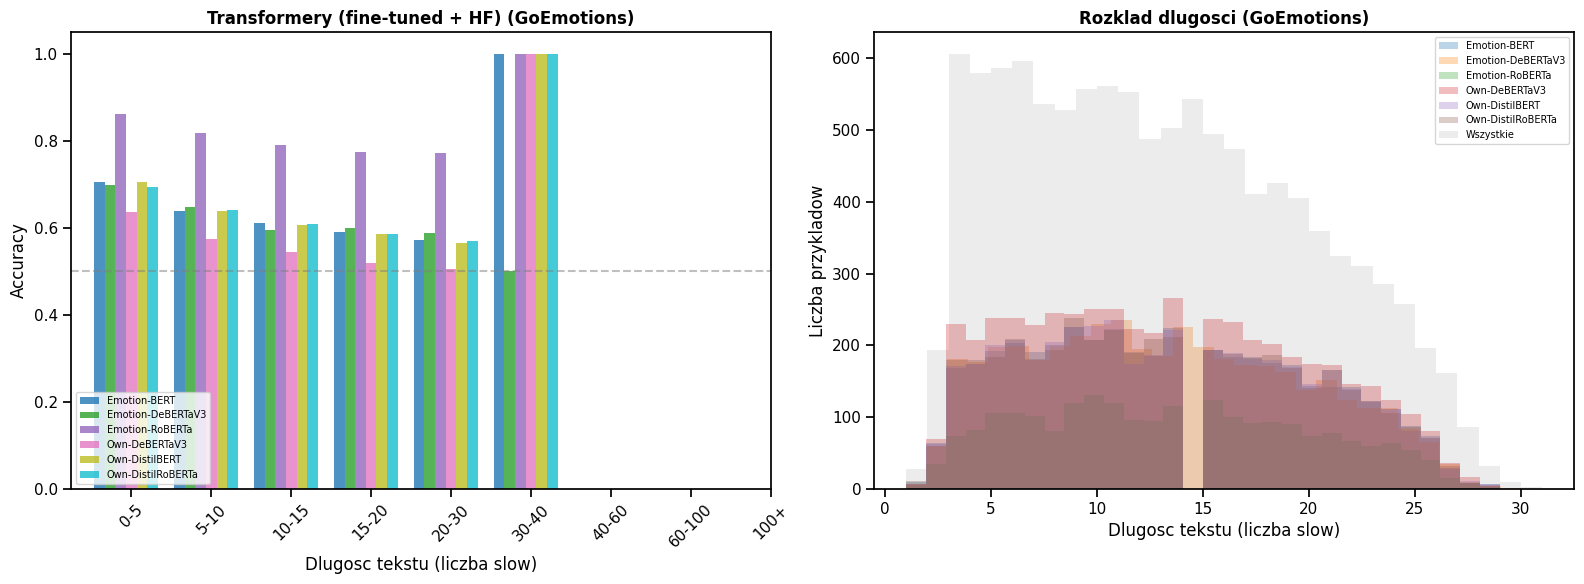

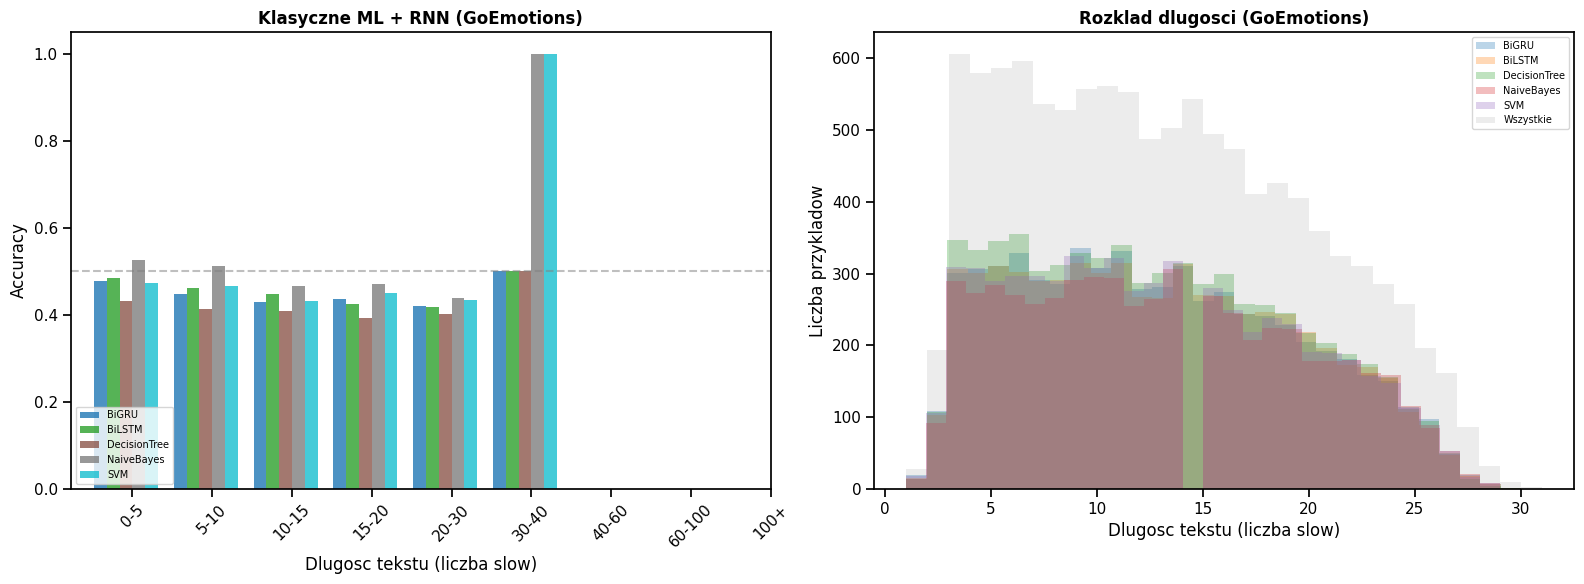


Procent blednych klasyfikacji per przedzial (GoEmotions):


,dlugosc,n,BiGRU,BiLSTM,DecisionTree,Emotion-BERT,Emotion-DeBERTaV3,Emotion-RoBERTa,NaiveBayes,Own-DeBERTaV3,Own-DistilBERT,Own-DistilRoBERTa,SVM
0,0-5,1407,52.2,51.5,56.9,29.5,30.2,13.8,47.3,36.4,29.4,30.5,52.6
1,5-10,2805,55.3,53.8,58.6,36.0,35.3,18.2,48.8,42.5,36.2,35.8,53.3
2,10-15,2648,57.0,55.2,59.1,38.9,40.4,21.0,53.4,45.6,39.4,39.2,56.9
3,15-20,2210,56.5,57.6,60.8,41.0,40.0,22.5,52.8,48.0,41.3,41.5,55.0
4,20-30,2020,57.9,58.2,59.8,42.8,41.2,22.7,56.2,49.6,43.6,43.1,56.5
5,30-40,2,50.0,50.0,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0


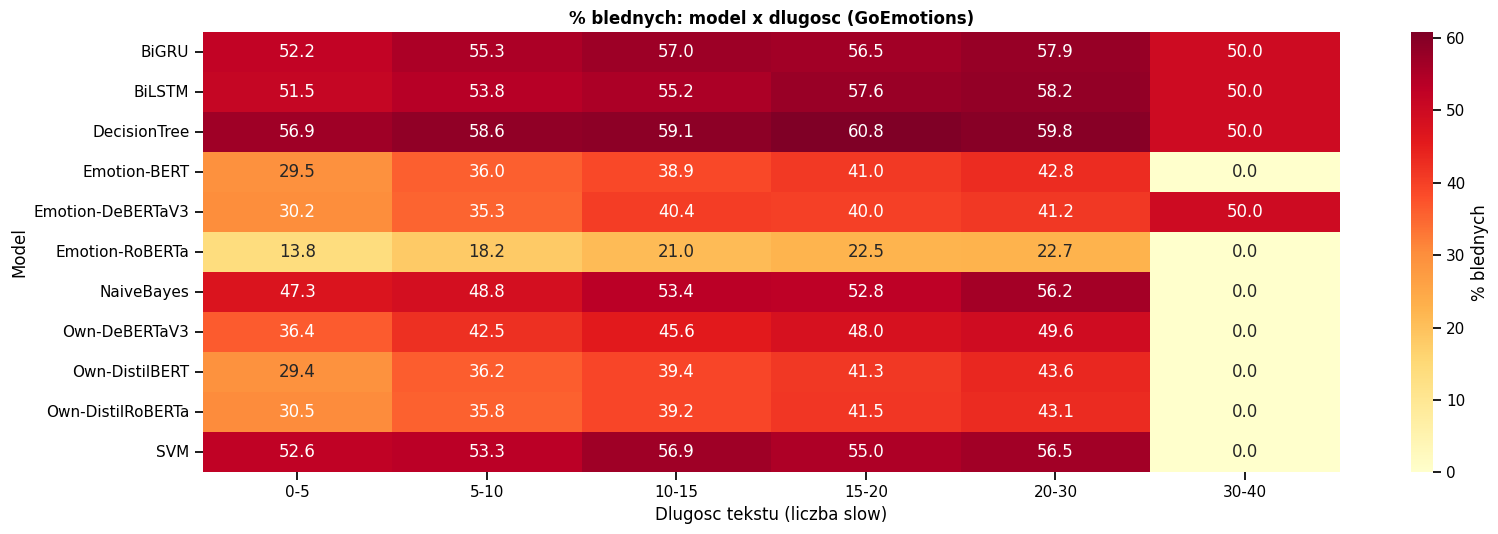


Test Manna-Whitneya (GoEmotions):
  BiGRU                     popr=12.32 slow | bledne=12.74 slow | p=0.000570
  BiLSTM                    popr=12.22 slow | bledne=12.82 slow | p=0.000001
  DecisionTree              popr=12.43 slow | bledne=12.64 slow | p=0.049771
  Emotion-BERT              popr=12.14 slow | bledne=13.23 slow | p=0.000000
  Emotion-DeBERTaV3         popr=12.22 slow | bledne=13.11 slow | p=0.000000
  Emotion-RoBERTa           popr=12.34 slow | bledne=13.40 slow | p=0.000000
  NaiveBayes                popr=12.13 slow | bledne=12.95 slow | p=0.000000
  Own-DeBERTaV3             popr=12.10 slow | bledne=13.12 slow | p=0.000000
  Own-DistilBERT            popr=12.13 slow | bledne=13.23 slow | p=0.000000
  Own-DistilRoBERTa         popr=12.14 slow | bledne=13.22 slow | p=0.000000
  SVM                       popr=12.34 slow | bledne=12.73 slow | p=0.001500

Dataset: Tripathi


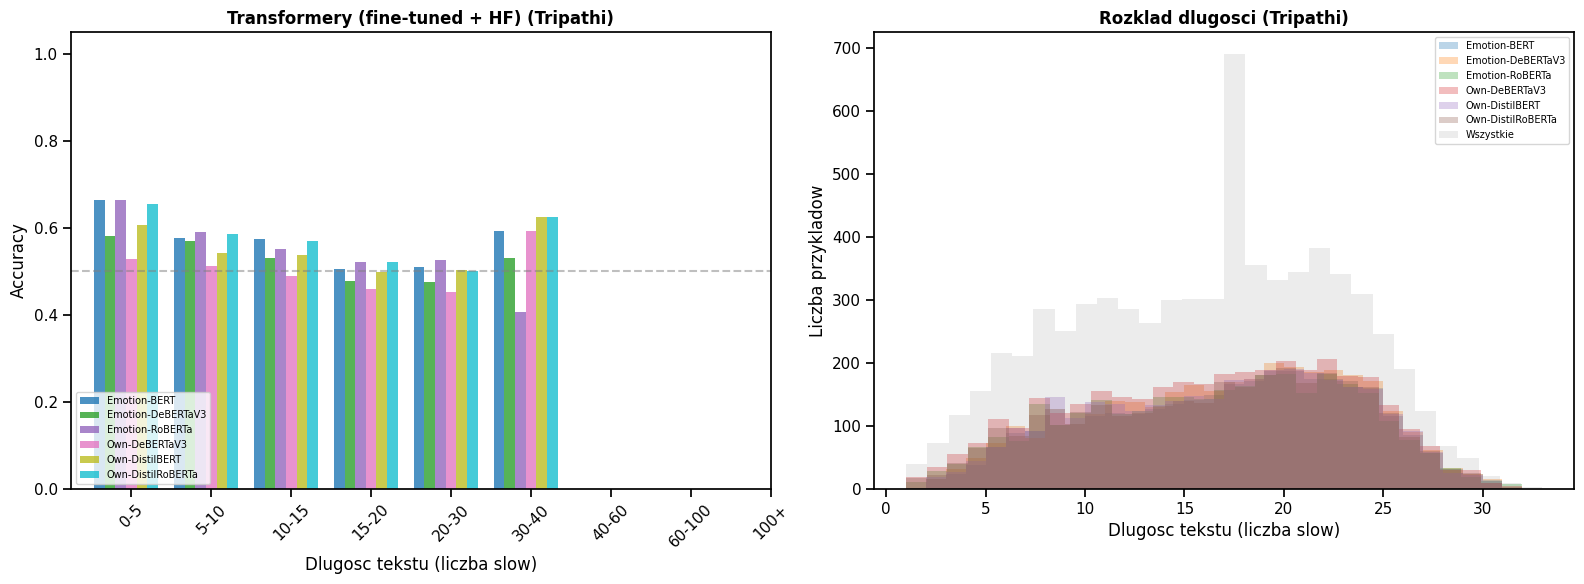

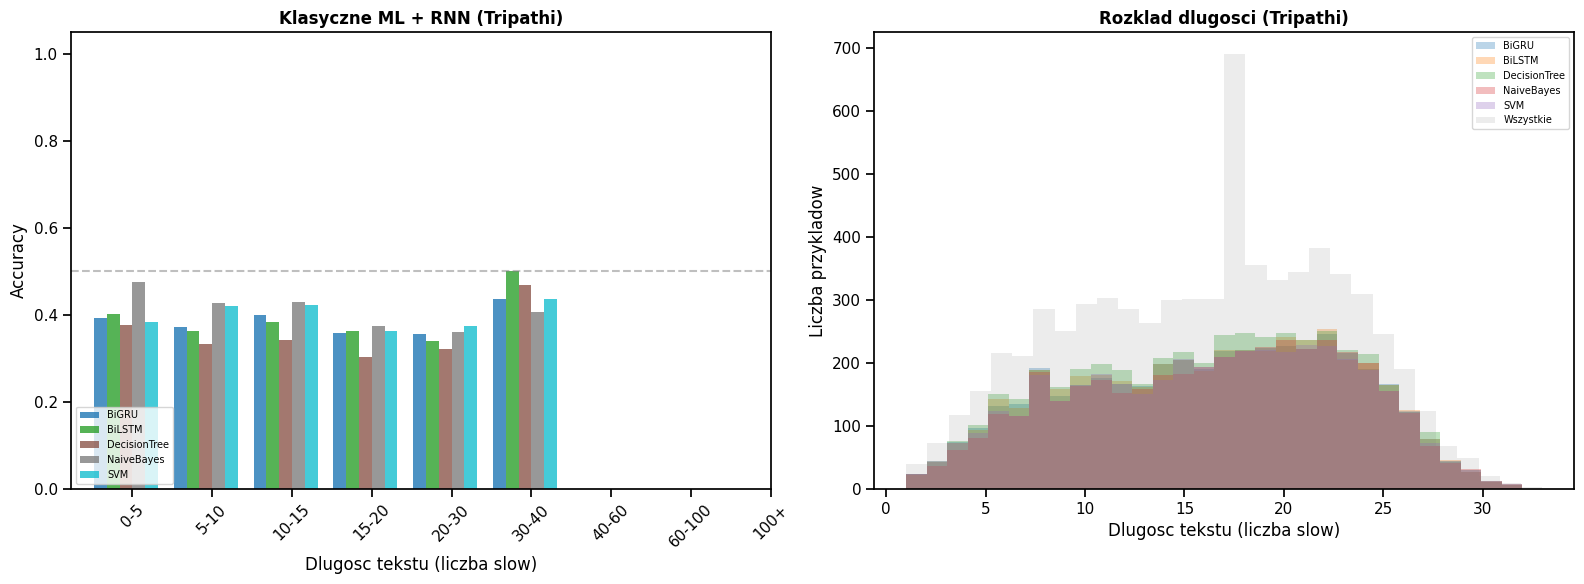


Procent blednych klasyfikacji per przedzial (Tripathi):


,dlugosc,n,BiGRU,BiLSTM,DecisionTree,Emotion-BERT,Emotion-DeBERTaV3,Emotion-RoBERTa,NaiveBayes,Own-DeBERTaV3,Own-DistilBERT,Own-DistilRoBERTa,SVM
0,0-5,229,60.7,59.8,62.4,33.6,41.9,33.6,52.4,47.2,39.3,34.5,61.6
1,5-10,1118,62.7,63.7,66.6,42.3,43.0,41.1,57.2,48.7,45.7,41.4,57.9
2,10-15,1447,60.1,61.6,65.8,42.6,46.9,44.9,57.2,51.1,46.3,43.1,57.7
3,15-20,1649,64.2,63.7,69.7,49.4,52.3,47.8,62.5,54.0,50.2,47.8,63.6
4,20-30,2388,64.4,66.0,67.8,49.0,52.5,47.3,64.0,54.7,49.6,50.0,62.5
5,30-40,32,56.2,50.0,53.1,40.6,46.9,59.4,59.4,40.6,37.5,37.5,56.2


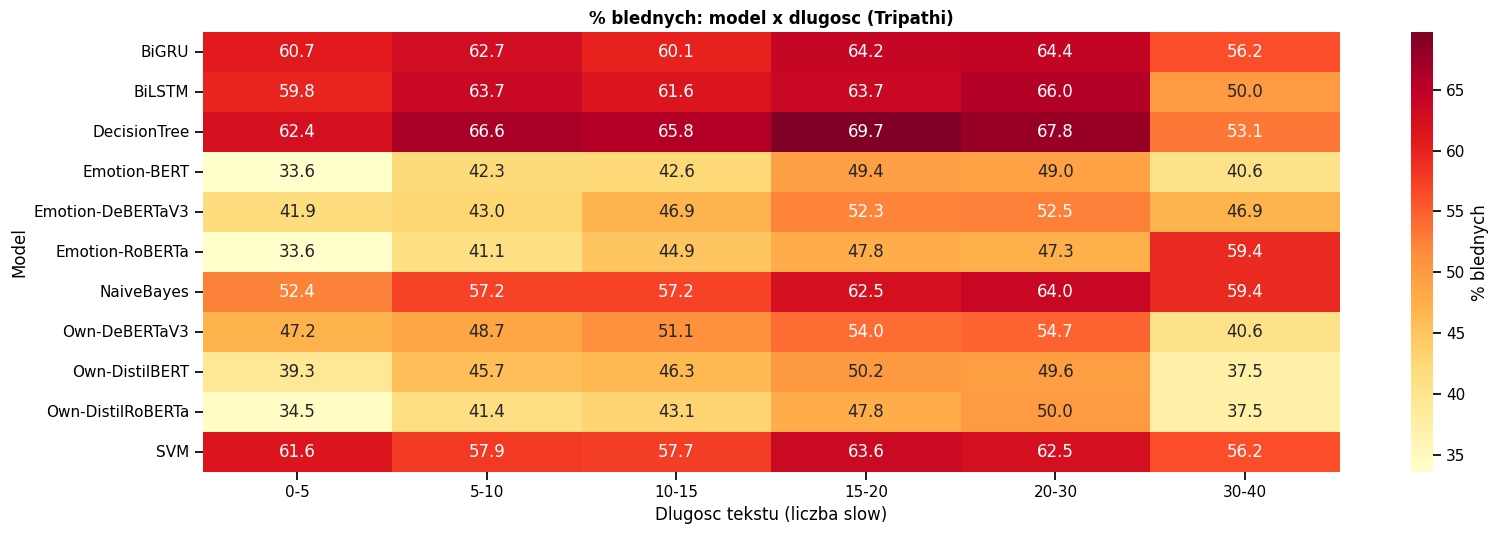


Test Manna-Whitneya (Tripathi):
  BiGRU                     popr=15.95 slow | bledne=16.24 slow | p=0.075860
  BiLSTM                    popr=15.95 slow | bledne=16.23 slow | p=0.077455
  DecisionTree              popr=16.01 slow | bledne=16.19 slow | p=0.312034
  Emotion-BERT              popr=15.75 slow | bledne=16.58 slow | p=0.000000
  Emotion-DeBERTaV3         popr=15.70 slow | bledne=16.57 slow | p=0.000000
  Emotion-RoBERTa           popr=15.82 slow | bledne=16.50 slow | p=0.000045
  NaiveBayes                popr=15.64 slow | bledne=16.45 slow | p=0.000001
  Own-DeBERTaV3             popr=15.86 slow | bledne=16.37 slow | p=0.001298
  Own-DistilBERT            popr=15.92 slow | bledne=16.35 slow | p=0.007588
  Own-DistilRoBERTa         popr=15.71 slow | bledne=16.62 slow | p=0.000000
  SVM                       popr=15.88 slow | bledne=16.29 slow | p=0.011238


In [19]:
if len(all_results) > 0:
    all_models = sorted([m for m in all_predictions])
    bins = [0, 5, 10, 15, 20, 30, 40, 60, 100, 200]
    bin_labels = ['0-5', '5-10', '10-15', '15-20', '20-30', '30-40', '40-60', '60-100', '100+']

    # Podzial modeli na dwie grupy do wykresow
    trans_models = [m for m in all_models if any(x in m for x in ['Own-', 'Emotion-'])]
    other_models = [m for m in all_models if m not in trans_models]

    for ds_name in EVAL_SETS:
        print(f'\n{"="*60}')
        print(f'Dataset: {ds_name}')
        print(f'{"="*60}')
        
        df = EVAL_SETS[ds_name]
        models_to_check = [m for m in all_models if ds_name in all_predictions[m]]
        
        text_lengths = np.array([len(t.split()) for t in df['text'].tolist()])
        bin_indices = np.clip(np.digitize(text_lengths, bins) - 1, 0, len(bin_labels) - 1)
        
        # --- 1. Wykresy slupkowe: accuracy vs dlugosc (dwie grupy) ---
        for group_name, group_models in [('Transformery (fine-tuned + HF)', [m for m in trans_models if m in models_to_check]),
                                          ('Klasyczne ML + RNN', [m for m in other_models if m in models_to_check])]:
            if len(group_models) == 0:
                continue
            
            acc_by_len = {}
            for m_name in group_models:
                y_true = all_predictions[m_name][ds_name]['y_true']
                y_pred = all_predictions[m_name][ds_name]['y_pred']
                correct = (y_true == y_pred).astype(float)
                bin_acc = []
                for bi in range(len(bin_labels)):
                    mask = bin_indices == bi
                    bin_acc.append(correct[mask].mean() if mask.sum() > 0 else np.nan)
                acc_by_len[m_name] = bin_acc
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            ax = axes[0]
            x = np.arange(len(bin_labels))
            w = 0.8 / len(group_models)
            colors = plt.cm.tab10(np.linspace(0, 1, len(group_models)))
            for i, (m_name, accs) in enumerate(acc_by_len.items()):
                valid = ~np.isnan(accs)
                ax.bar(x[valid] + i*w - w*len(group_models)/2,
                       [accs[j] for j in range(len(accs)) if valid[j]],
                       w, label=m_name, alpha=0.8, color=colors[i])
            ax.set_xticks(x)
            ax.set_xticklabels(bin_labels, rotation=45)
            ax.set_xlabel('Dlugosc tekstu (liczba slow)')
            ax.set_ylabel('Accuracy')
            ax.set_title(f'{group_name} ({ds_name})', fontweight='bold')
            ax.legend(fontsize=7, loc='lower left')
            ax.set_ylim(0, 1.05)
            ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
            
            ax = axes[1]
            for m_name in group_models:
                y_true = all_predictions[m_name][ds_name]['y_true']
                y_pred = all_predictions[m_name][ds_name]['y_pred']
                wrong = (y_true != y_pred)
                ax.hist(text_lengths[wrong], bins=30, alpha=0.3, label=m_name)
            ax.hist(text_lengths, bins=30, alpha=0.15, color='gray', label='Wszystkie')
            ax.set_xlabel('Dlugosc tekstu (liczba slow)')
            ax.set_ylabel('Liczba przykladow')
            ax.set_title(f'Rozklad dlugosci ({ds_name})', fontweight='bold')
            ax.legend(fontsize=7)
            
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / f'text_length_{group_name.replace(" ","_")}_{ds_name}.png', dpi=150)
            plt.show()
        
        # --- 2. Tabelka: % bledow ---
        print(f'\nProcent blednych klasyfikacji per przedzial ({ds_name}):')
        err_rows = []
        for bi, bl in enumerate(bin_labels):
            mask = bin_indices == bi
            if mask.sum() > 0:
                row = {'dlugosc': bl, 'n': mask.sum()}
                for m_name in models_to_check:
                    y_true = all_predictions[m_name][ds_name]['y_true']
                    y_pred = all_predictions[m_name][ds_name]['y_pred']
                    row[m_name] = round((y_true[mask] != y_pred[mask]).mean() * 100, 1)
                err_rows.append(row)
        
        err_df = pd.DataFrame(err_rows)
        display(err_df.style.background_gradient(cmap='YlOrRd', subset=models_to_check).format(precision=1))
        err_df.to_csv(REPORTS_DIR / f'text_length_error_{ds_name}.csv', index=False)
        
        # --- 3. Heatmapa: % bledow ---
        plt.figure(figsize=(max(10, len(models_to_check) * 1.5), max(5, len(models_to_check) * 0.5)))
        heat = err_df.set_index('dlugosc').drop(columns='n')
        sns.heatmap(heat.T.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
                    cbar_kws={'label': '% blednych'})
        plt.title(f'% blednych: model x dlugosc ({ds_name})', fontweight='bold')
        plt.xlabel('Dlugosc tekstu (liczba slow)')
        plt.ylabel('Model')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f'text_length_heatmap_{ds_name}.png', dpi=150)
        plt.show()
        
        # --- 4. Test Manna-Whitneya ---
        from scipy.stats import mannwhitneyu
        print(f'\nTest Manna-Whitneya ({ds_name}):')
        for m_name in models_to_check:
            y_true = all_predictions[m_name][ds_name]['y_true']
            y_pred = all_predictions[m_name][ds_name]['y_pred']
            correct_mask = (y_true == y_pred)
            wrong_mask = (y_true != y_pred)
            if wrong_mask.sum() > 0 and correct_mask.sum() > 0:
                stat, p = mannwhitneyu(text_lengths[correct_mask], text_lengths[wrong_mask])
                print(f'  {m_name:25s} popr={text_lengths[correct_mask].mean():.2f} slow | bledne={text_lengths[wrong_mask].mean():.2f} slow | p={p:.6f}')

---

## Blok III — Wnioski i podsumowanie

---

### Rankingi i podsumowanie wyników

Zestawienie wszystkich wyników — ranking modeli według średniej macro F1 po wszystkich datasetach, najlepszy model na każdym zbiorze testowym, oraz finalne podsumowanie plików wyjściowych.

---


In [20]:
if len(results_df) > 0:
    summary = results_df.groupby('model').agg({'macro_f1': 'mean', 'accuracy': 'mean'}).sort_values('macro_f1', ascending=False)
    print('===== PODSUMOWANIE =====')
    print(summary.round(4))

    print('\n--- Ranking modeli (średnia macro F1) ---')
    for i, (m, row) in enumerate(summary.iterrows(), 1):
        print(f'{i}. {m:25s} macro_f1={row["macro_f1"]:.4f}  acc={row["accuracy"]:.4f}')

    print('\n--- Per-dataset top-1 ---')
    for ds in results_df['dataset'].unique():
        sub = results_df[results_df['dataset'] == ds]
        best = sub.loc[sub['macro_f1'].idxmax()]
        print(f'{ds:20s} -> {best["model"]:25s} macro_f1={best["macro_f1"]:.4f}')

    summary.to_csv(REPORTS_DIR / 'model_ranking.csv')

    print('\n--- Per-dataset wyniki ---')
    for ds in sorted(results_df['dataset'].unique()):
        sub = results_df[results_df['dataset'] == ds].sort_values('macro_f1', ascending=False)
        print(f'\n{ds}:')
        for _, r in sub.iterrows():
            mname = r['model']; mf1 = r['macro_f1']; acc = r['accuracy']
            print(f'  {mname:25s} macro_f1={mf1:.4f}  acc={acc:.4f}')
    print('\nWyniki zapisane w reports/')

print('\nPliki:')
print('Checkpoints:', list(CHECKPOINT_DIR.glob('*')))
print('Plots:', list(PLOTS_DIR.glob('*.png')))
print('Reports:', list(REPORTS_DIR.glob('*')))

===== PODSUMOWANIE =====
                   macro_f1  accuracy
model                                
Own-DistilRoBERTa    0.7004    0.7133
Emotion-BERT         0.6967    0.7100
Own-DistilBERT       0.6948    0.7067
Emotion-DeBERTaV3    0.6941    0.7086
Own-DeBERTaV3        0.6498    0.6709
Emotion-RoBERTa      0.6355    0.6422
SVM                  0.5835    0.5934
NaiveBayes           0.5807    0.5923
BiGRU                0.5625    0.5790
BiLSTM               0.5558    0.5798
DecisionTree         0.4618    0.5062

--- Ranking modeli (średnia macro F1) ---
1. Own-DistilRoBERTa         macro_f1=0.7004  acc=0.7133
2. Emotion-BERT              macro_f1=0.6967  acc=0.7100
3. Own-DistilBERT            macro_f1=0.6948  acc=0.7067
4. Emotion-DeBERTaV3         macro_f1=0.6941  acc=0.7086
5. Own-DeBERTaV3             macro_f1=0.6498  acc=0.6709
6. Emotion-RoBERTa           macro_f1=0.6355  acc=0.6422
7. SVM                       macro_f1=0.5835  acc=0.5934
8. NaiveBayes                macro_f1=0

---

## Eksperyment 5 — Dataset Fusion (łączenie datasetów)

**Pytanie badawcze:** Czy trenowanie na połączeniu wielu datasetów poprawia generalizację?

**Motywacja:**  
Model trenowany tylko na Combined może „nauczyć się" specyficznego stylu tego datasetu, co prowadzi do słabych wyników na ISEAR i GoEmotions. Dodanie tych danych do treningu może wypełnić tę lukę.

**Testowane warianty:**

| Wariant | Skład | Rozmiar |
|---|---|---|
| **Fusion-3 (All)** | Combined + ISEAR + GoEmotions | ~55k próbek |
| **Ewaluacja** | Praveen + Tripathi (out-of-domain) | ~36k próbek |

**Modele Fusion:**  
Te same architektury (DistilBERT, DistilRoBERTa, DeBERTaV3), ale trenowane na pełnym zbiorze Fusion-3. Wyniki porównywane z modelami Own-* (trenowanymi tylko na Combined).

> **Uwaga:** Aby sprawdzić generalizację, modele Fusion są ewaluowane na **Praveen i Tripathi** — dwóch datasetach out-of-domain, których model nie widział podczas treningu ani walidacji.

---


===== Scalenie 3 datasetów =====
Połączony dataset: 55376 próbek
Praveen (eval): 17627 próbek
Tripathi (eval): 6863 próbek
emotion
anger      14911
joy        14397
sadness    13811
fear       12257
Name: count, dtype: int64

Ensemble Train: 38763, Val: 8306, Test: 8307

Nowy test set — rozkład klas:
emotion
anger      2237
joy        2160
sadness    2072
fear       1838
Name: count, dtype: int64


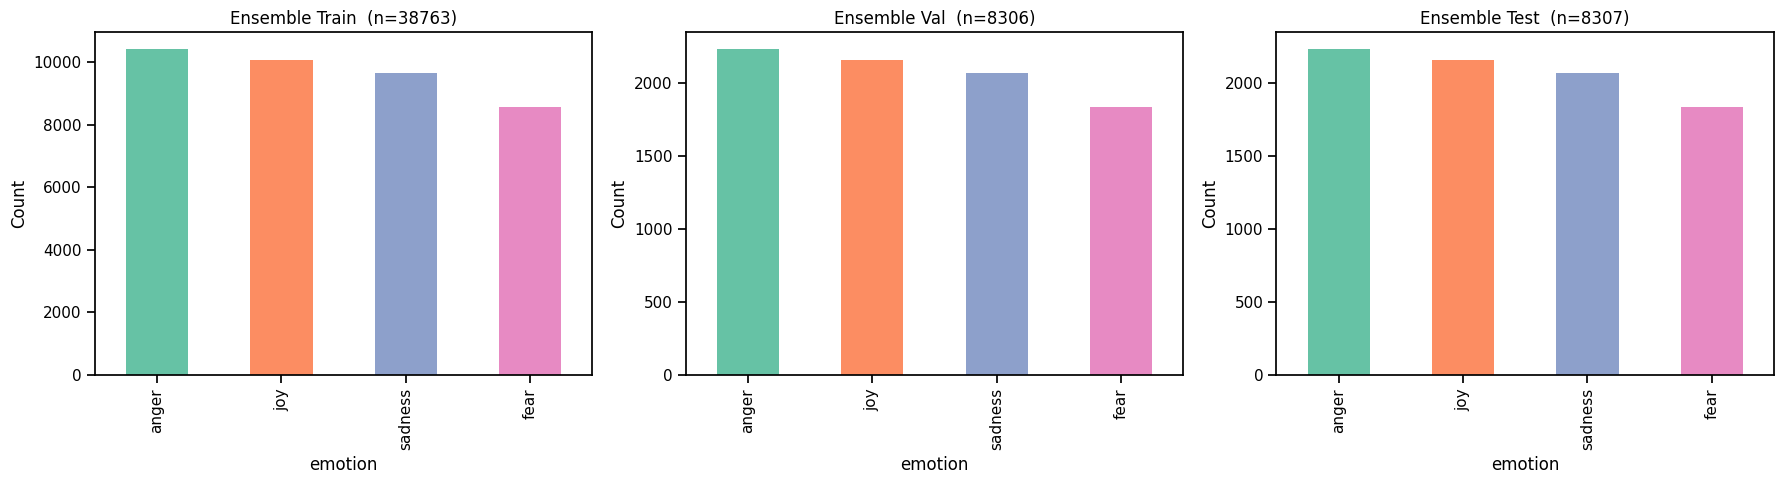

['checkpoints/ensemble_label_encoder.joblib']

In [21]:
print('===== Scalenie 3 datasetów =====')
ensemble_raw = pd.concat([
    combined[['text', 'emotion']],
    isear[['text', 'emotion']],
    goemotions[['text', 'emotion']]
], ignore_index=True)
print(f'Połączony dataset: {len(ensemble_raw)} próbek')

# Wczytaj Praveen i Tripathi — czysta ewaluacja out-of-domain
praveen_eval = load_external(CONFIG['praveen_path'], CONFIG['target_emotions'])
tripathi_eval = load_external(CONFIG['tripathi_path'], CONFIG['target_emotions'])
if praveen_eval is not None:
    print(f'Praveen (eval): {len(praveen_eval)} próbek')
if tripathi_eval is not None:
    print(f'Tripathi (eval): {len(tripathi_eval)} próbek')
print(ensemble_raw['emotion'].value_counts())

ensemble_raw['label'] = ensemble_raw['emotion'].map({l: i for i, l in enumerate(label_names)})
ensemble_raw = ensemble_raw.dropna(subset=['label'])
ensemble_raw['label'] = ensemble_raw['label'].astype(int)

ens_train_df, temp_df = train_test_split(
    ensemble_raw, test_size=0.3, stratify=ensemble_raw['label'], random_state=SEED
)
ens_val_df, ens_test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)

print(f'\nEnsemble Train: {len(ens_train_df)}, Val: {len(ens_val_df)}, Test: {len(ens_test_df)}')
print(f'\nNowy test set — rozkład klas:')
print(ens_test_df['emotion'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, df) in zip(axes, [('Ensemble Train', ens_train_df), ('Ensemble Val', ens_val_df), ('Ensemble Test', ens_test_df)]):
    df['emotion'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
    ax.set_title(f'{name}  (n={len(df)})')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ensemble_distributions.png', dpi=150)
plt.show()

joblib.dump(label_encoder, CHECKPOINT_DIR / 'ensemble_label_encoder.joblib')

In [22]:
print('\n' + '='*70)
print('Trening 3 własnych transformerów na zbiorze Ensemble')
print('Checkpointy: Fusion-DistilBERT, Fusion-DistilRoBERTa, Fusion-DeBERTaV3')
print('='*70)

fusion_models = {
    'Fusion-DistilBERT': 'distilbert-base-uncased',
    'Fusion-DistilRoBERTa': 'distilroberta-base',
    'Fusion-DeBERTaV3': 'microsoft/deberta-v3-base',
}

fusion_predict_fns = {}

if HF_AVAILABLE:
    for alias, model_name in fusion_models.items():
        t0_fus = time.time()
        out_dir = CHECKPOINT_DIR / f'hf_{alias}'
        best_path = out_dir / 'best'

        if best_path.exists() and (best_path / 'config.json').exists():
            print(f'Loading {alias} from {best_path}...')
            tokenizer = AutoTokenizer.from_pretrained(str(best_path))
            model = AutoModelForSequenceClassification.from_pretrained(
                str(best_path), torch_dtype=torch.float32,
                ignore_mismatched_sizes=True,
            ).to(DEVICE)
        else:
            print(f'\n===== Fine-tuning {alias} ({model_name}) =====')
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token else '[PAD]'

            model = AutoModelForSequenceClassification.from_pretrained(
                model_name, num_labels=num_labels,
                id2label={i: l for i, l in enumerate(label_names)},
                label2id={l: i for i, l in enumerate(label_names)},
                torch_dtype=torch.float32,
                ignore_mismatched_sizes=True,
            )
            if 'DeBERTaV3' not in alias:
                try:
                    model.gradient_checkpointing_enable()
                except:
                    pass

            train_ds = HFDataset(ens_train_df, tokenizer, CONFIG['tfm_max_len'])
            val_ds = HFDataset(ens_val_df, tokenizer, CONFIG['tfm_max_len'])

            args = TrainingArguments(
                output_dir=str(out_dir),
                eval_strategy='epoch',
                save_strategy='epoch',
                learning_rate=CONFIG['learning_rate_transformer'],
                per_device_train_batch_size=CONFIG['batch_size_tfm'],
                per_device_eval_batch_size=CONFIG['batch_size_tfm'] * 2,
                num_train_epochs=CONFIG['transformer_epochs'],
                weight_decay=0.01,
                load_best_model_at_end=True,
                metric_for_best_model='macro_f1',
                greater_is_better=True,
                logging_steps=50,
                report_to='none',
                seed=SEED,
                fp16=CONFIG['use_fp16'] and alias != 'Fusion-DeBERTaV3',
                dataloader_num_workers=0,
                save_total_limit=1,
            )
            trainer = Trainer(
                model=model, args=args,
                train_dataset=train_ds, eval_dataset=val_ds,
                data_collator=DataCollatorWithPadding(tokenizer),
                compute_metrics=compute_metrics_hf,
            )
            trainer.train()
            trainer.save_model(str(best_path))
            tokenizer.save_pretrained(str(best_path))
            save_training_time(alias, time.time() - t0_fus)
        if alias not in training_times:
            training_times[alias] = {'training_time_sec': None, 'timestamp': 'loaded from checkpoint'}
            TRAINING_TIMES_PATH.write_text(json.dumps(training_times, indent=2))

        def make_fusion_predict_fn(model, tokenizer):
            collator = DataCollatorWithPadding(tokenizer)
            def predict_fn(texts):
                ds = HFDataset(pd.DataFrame({'text': texts, 'label': [0]*len(texts)}), tokenizer, CONFIG['tfm_max_len'])
                model.eval()
                loader = DataLoader(ds, batch_size=CONFIG['batch_size_tfm'] * 2, collate_fn=collator, num_workers=0)
                all_logits = []
                with torch.no_grad():
                    for batch in loader:
                        inputs = {k: v.to(model.device) for k, v in batch.items() if k != 'labels'}
                        logits = model(**inputs).logits
                        all_logits.append(logits.cpu())
                y_proba = torch.softmax(torch.cat(all_logits), dim=-1).numpy()
                y_pred = y_proba.argmax(axis=1)
                return y_pred, y_proba
            return predict_fn

        fusion_predict_fns[alias] = make_fusion_predict_fn(model, tokenizer)
else:
    print('HF not available - cannot train fusion models')


Trening 3 własnych transformerów na zbiorze Ensemble
Checkpointy: Fusion-DistilBERT, Fusion-DistilRoBERTa, Fusion-DeBERTaV3
Loading Fusion-DistilBERT from checkpoints/hf_Fusion-DistilBERT/best...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading Fusion-DistilRoBERTa from checkpoints/hf_Fusion-DistilRoBERTa/best...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading Fusion-DeBERTaV3 from checkpoints/hf_Fusion-DeBERTaV3/best...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [23]:
print('\n' + '='*70)
print('Ewaluacja na Praveen + Tripathi (out-of-domain)')
print('='*70)

ensemble_results = []
ensemble_predictions = defaultdict(dict)

eval_datasets = {}
if praveen_eval is not None:
    eval_datasets['Praveen'] = praveen_eval.rename(columns={'emotion': 'label'})
if tripathi_eval is not None:
    eval_datasets['Tripathi'] = tripathi_eval.rename(columns={'emotion': 'label'})

def evaluate_ood(model_name, predict_fn):
    for ds_name, df in eval_datasets.items():
        y_true = df['label'].map({n: i for i, n in enumerate(label_names)}).values
        y_pred, y_proba = predict_fn(df['text'].tolist())
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
        w_prec, w_rec, w_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        bacc = balanced_accuracy_score(y_true, y_pred)
        result = {
            'model': model_name, 'dataset': ds_name,
            'accuracy': acc, 'balanced_accuracy': bacc,
            'macro_precision': precision, 'macro_recall': recall,
            'macro_f1': f1, 'weighted_f1': w_f1,
        }
        ensemble_results.append(result)
        ensemble_predictions[model_name][ds_name] = {'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba}
        print(f'  {model_name:25s} | {ds_name:10s}  acc={acc:.4f}  macro_f1={f1:.4f}  w_f1={w_f1:.4f}')

for name, fn in fusion_predict_fns.items():
    print(f'\n=== {name} ===')
    evaluate_ood(name, fn)

if 'Pretrained' in CONFIG['active_models'] and HF_AVAILABLE:
    from transformers import pipeline
    pretrained_models = {
        'Emotion-RoBERTa': CONFIG['pretrained_emotion_roberta'],
        'Emotion-BERT': CONFIG['pretrained_emotion_bert'],
        'Emotion-DeBERTaV3': CONFIG['pretrained_emotion_deberta'],
    }
    for pname, pmodel in pretrained_models.items():
        print(f'\n=== {pname} ===')
        try:
            clf = pipeline('text-classification', model=pmodel, top_k=None, device=0 if DEVICE == 'cuda' else -1)
            def predict_pretrained_ood(texts, pipe=clf):
                preds, probas = [], []
                for text in tqdm(texts, desc=pname):
                    outputs = pipe(text)[0]
                    scores = np.zeros(num_labels, dtype=float)
                    has_any = False
                    mapping = {
                        'anger': 'anger', 'angry': 'anger',
                        'joy': 'joy', 'happy': 'joy', 'happiness': 'joy',
                        'sadness': 'sadness', 'sad': 'sadness',
                        'fear': 'fear', 'frightened': 'fear', 'scared': 'fear',
                    }
                    for o in outputs:
                        lab = o['label'].strip().lower()
                        if lab in label_names:
                            scores[label_names.index(lab)] += float(o['score'])
                            has_any = True
                    if not has_any:
                        for o in outputs:
                            lab = o['label'].strip().lower()
                            mapped = mapping.get(lab)
                            if mapped and mapped in label_names:
                                scores[label_names.index(mapped)] += float(o['score'])
                                has_any = True
                    if not has_any:
                        scores[0] = 1.0
                    else:
                        scores /= scores.sum()
                    probas.append(scores)
                    preds.append(scores.argmax())
                return np.array(preds), np.array(probas)
            evaluate_ood(pname, predict_pretrained_ood)
        except Exception as e:
            print(f'  Failed {pname}: {e}')

ensemble_results_df = pd.DataFrame(ensemble_results)
ensemble_results_df.to_csv(REPORTS_DIR / 'ensemble_results.csv', index=False)
print(f'\nZapisano wyniki: reports/ensemble_results.csv')


Ewaluacja na Praveen + Tripathi (out-of-domain)

=== Fusion-DistilBERT ===
  Fusion-DistilBERT         | Praveen     acc=0.9734  macro_f1=0.9652  w_f1=0.9735
  Fusion-DistilBERT         | Tripathi    acc=0.5697  macro_f1=0.5636  w_f1=0.5629

=== Fusion-DistilRoBERTa ===
  Fusion-DistilRoBERTa      | Praveen     acc=0.9728  macro_f1=0.9646  w_f1=0.9730
  Fusion-DistilRoBERTa      | Tripathi    acc=0.5805  macro_f1=0.5734  w_f1=0.5715

=== Fusion-DeBERTaV3 ===
  Fusion-DeBERTaV3          | Praveen     acc=0.9747  macro_f1=0.9667  w_f1=0.9749
  Fusion-DeBERTaV3          | Tripathi    acc=0.5906  macro_f1=0.5855  w_f1=0.5843

=== Emotion-RoBERTa ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Emotion-RoBERTa: 100%|████████████████████████████████████████████████████████████| 17627/17627 [05:02<00:00, 58.19it/s]


  Emotion-RoBERTa           | Praveen     acc=0.6520  macro_f1=0.5921  w_f1=0.6478


Emotion-RoBERTa: 100%|██████████████████████████████████████████████████████████████| 6863/6863 [02:02<00:00, 56.11it/s]


...

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Emotion-DeBERTaV3: 100%|██████████████████████████████████████████████████████████| 17627/17627 [13:35<00:00, 21.62it/s]


  Emotion-DeBERTaV3         | Praveen     acc=0.9842  macro_f1=0.9790  w_f1=0.9842


Emotion-DeBERTaV3: 100%|████████████████████████████████████████████████████████████| 6863/6863 [04:42<00:00, 24.33it/s]


  Emotion-DeBERTaV3         | Tripathi    acc=0.5065  macro_f1=0.4899  w_f1=0.4789

Zapisano wyniki: reports/ensemble_results.csv



Wizualizacje wyników Ensemble


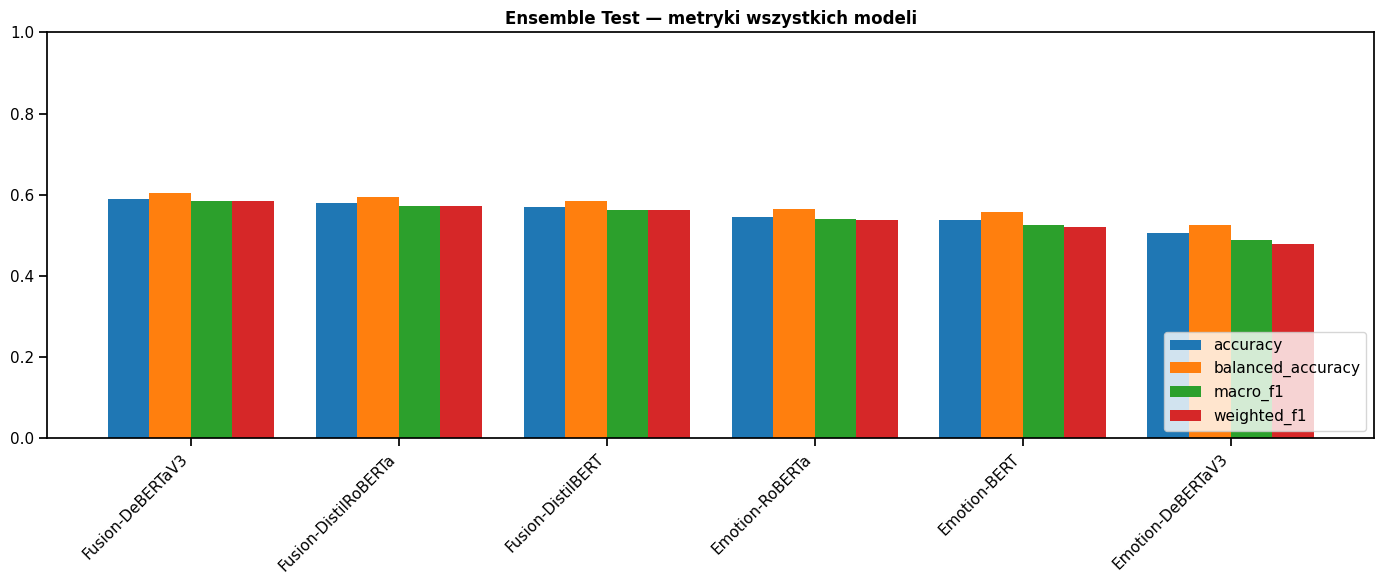

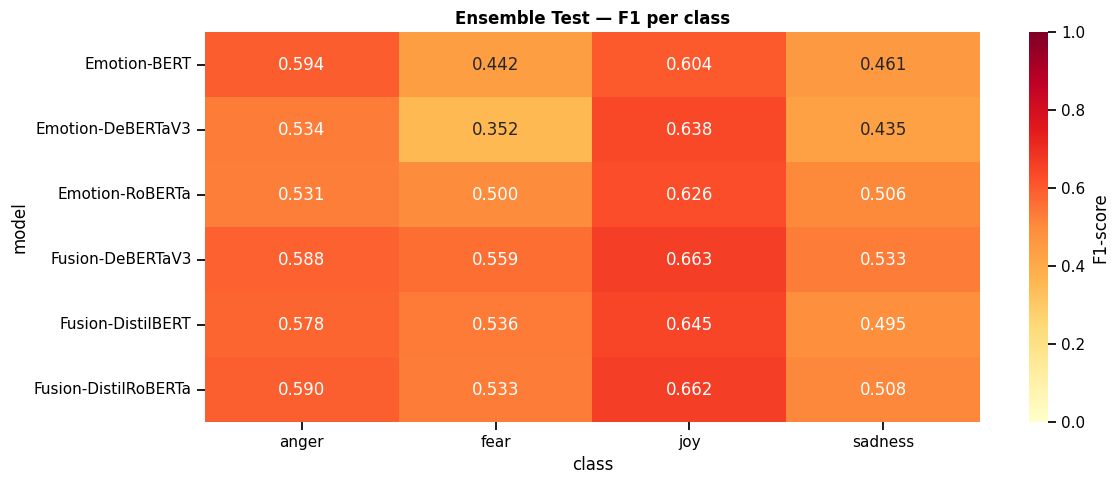

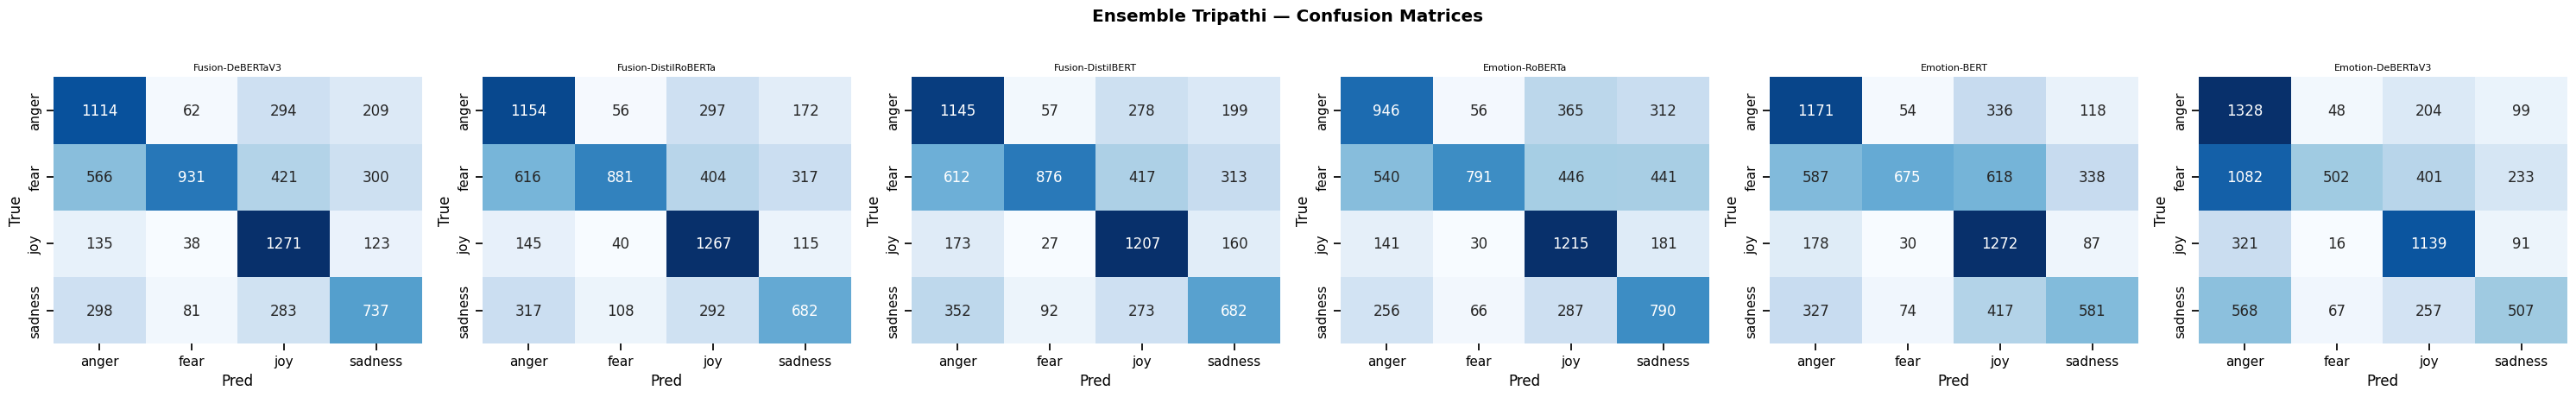

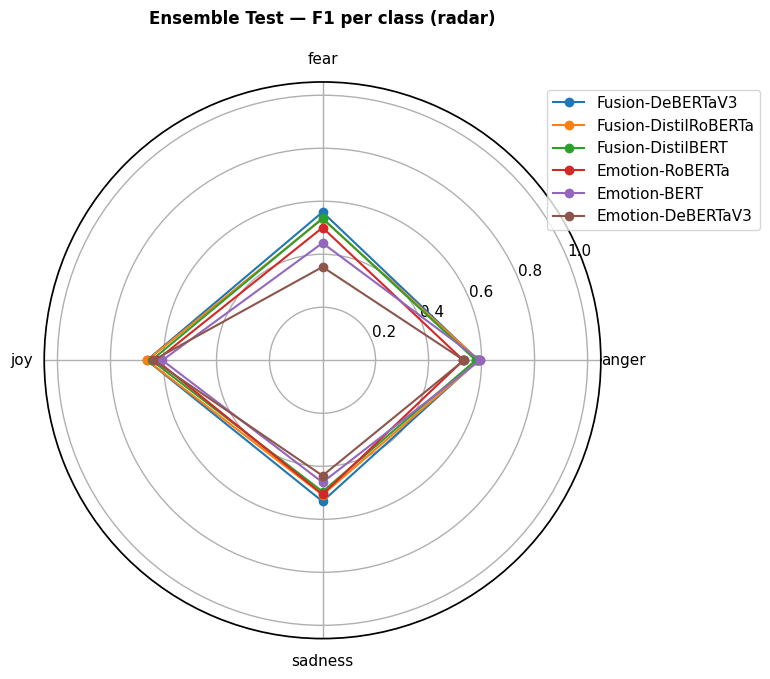

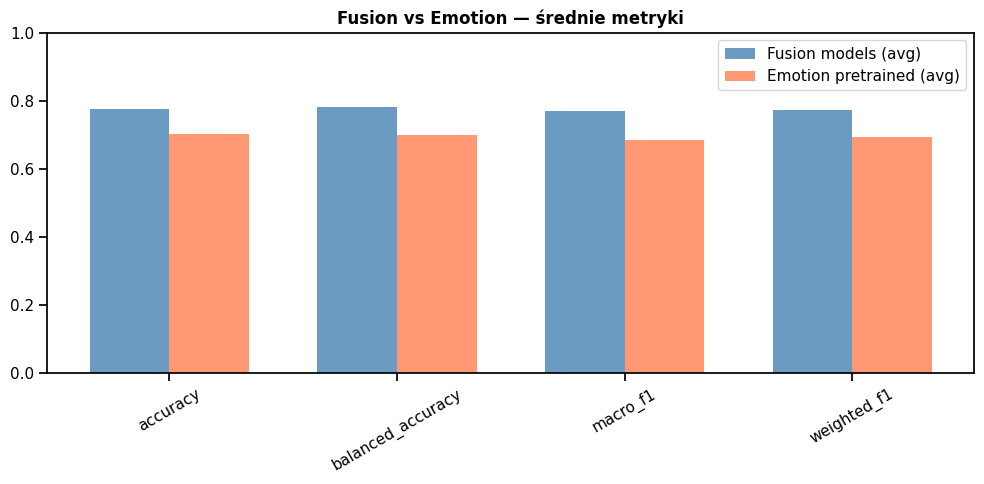

Wizualizacje zapisane w plots/


In [24]:
print('\n' + '='*70)
print('Wizualizacje wyników Ensemble')
print('='*70)

if len(ensemble_results) > 0:
    metrics = ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']
    # Użyj tylko Tripathi (każdy model raz)
    sub = ensemble_results_df[ensemble_results_df['dataset'] == 'Tripathi'].sort_values('macro_f1', ascending=False).reset_index(drop=True)

    # 1. Grouped bar
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(sub))
    w = 0.2
    for i, m in enumerate(metrics):
        ax.bar(x + i*w - 1.5*w, sub[m].values, w, label=m)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['model'].values, rotation=45, ha='right')
    ax.set_title('Ensemble Test — metryki wszystkich modeli', fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'ensemble_comparison_grouped.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Per-class F1 heatmap
    per_class_data = []
    for _, row in sub.iterrows():
        m = row['model']
        if m in ensemble_predictions and 'Tripathi' in ensemble_predictions[m]:
            d = ensemble_predictions[m]['Tripathi']
            cr = classification_report(d['y_true'], d['y_pred'], target_names=label_names, zero_division=0, output_dict=True)
            for label in label_names:
                per_class_data.append({'model': m, 'class': label, 'f1': cr[label]['f1-score']})
    if per_class_data:
        per_class_df = pd.DataFrame(per_class_data)
        pivot = per_class_df.pivot_table(index='model', columns='class', values='f1', aggfunc='first')
        plt.figure(figsize=(12, max(5, len(sub)*0.5)))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1, cbar_kws={'label': 'F1-score'})
        plt.title('Ensemble Test — F1 per class', fontweight='bold')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'ensemble_per_class_f1.png', dpi=150)
        plt.show()

    # 3. Confusion matrix grid --- tylko modele z danymi
    model_order = [m for m in sub["model"].values if m in ensemble_predictions and "Tripathi" in ensemble_predictions[m]]
    if model_order:
        fig, axes = plt.subplots(1, len(model_order), figsize=(5*len(model_order), 4.5), squeeze=False)
        for i, model_name in enumerate(model_order):
            ax = axes[0, i]
            d = ensemble_predictions[model_name]["Tripathi"]
            cm = confusion_matrix(d["y_true"], d["y_pred"])
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax, cbar=False)
            ax.set_title(f"{model_name}", fontsize=8)
            ax.set_xlabel("Pred")
            ax.set_ylabel("True")
        plt.suptitle("Ensemble Tripathi — Confusion Matrices", fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "ensemble_confusion_grid.png", dpi=150, bbox_inches="tight")
        plt.show()

    # 4. Radar chart
    from math import pi
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    angles = [n / 4 * 2 * pi for n in range(4)] + [0]
    for model_name in model_order:
        if model_name in ensemble_predictions and 'Tripathi' in ensemble_predictions[model_name]:
            d = ensemble_predictions[model_name]['Tripathi']
            cr = classification_report(d['y_true'], d['y_pred'], target_names=label_names, zero_division=0, output_dict=True)
            vals = [cr[l]['f1-score'] for l in label_names] + [cr[label_names[0]]['f1-score']]
            ax.plot(angles, vals, 'o-', label=model_name)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(label_names)
    ax.set_ylim(0, 1.05)
    ax.set_title('Ensemble Test — F1 per class (radar)', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'ensemble_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 5. Fusion vs Emotion bar
    fusion_models_list = [m for m in model_order if 'Fusion' in m]
    emotion_models_list = [m for m in model_order if 'Emotion' in m]
    if fusion_models_list and emotion_models_list:
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(metrics))
        w = 0.35
        fusion_avg = ensemble_results_df[ensemble_results_df['model'].isin(fusion_models_list)][metrics].mean().values
        emotion_avg = ensemble_results_df[ensemble_results_df['model'].isin(emotion_models_list)][metrics].mean().values
        ax.bar(x - w/2, fusion_avg, w, label='Fusion models (avg)', alpha=0.8, color='steelblue')
        ax.bar(x + w/2, emotion_avg, w, label='Emotion pretrained (avg)', alpha=0.8, color='coral')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics, rotation=30)
        ax.set_ylim(0, 1)
        ax.set_title('Fusion vs Emotion — średnie metryki', fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'ensemble_fusion_vs_emotion.png', dpi=150)
        plt.show()

print('Wizualizacje zapisane w plots/')

In [25]:
print('='*70)
print('PODSUMOWANIE ENSEMBLE TRAINING')
print('='*70)

if len(ensemble_results) > 0:
    summary = ensemble_results_df.groupby('model').agg({'macro_f1': 'mean', 'accuracy': 'mean'}).sort_values('macro_f1', ascending=False)
    print(summary.round(4))

    print('\n--- Ranking modeli (macro F1) ---')
    for i, (m, row) in enumerate(summary.iterrows(), 1):
        print(f'{i}. {m:30s} macro_f1={row["macro_f1"]:.4f}  acc={row["accuracy"]:.4f}')

    best_model = summary.index[0]
    print(f'\nNajlepszy model na Ensemble Test: {best_model}')

    if best_model in ensemble_predictions and 'Tripathi' in ensemble_predictions[best_model]:
        d = ensemble_predictions[best_model]['Tripathi']
        print(f'\n--- Classification report: {best_model} ---')
        print(classification_report(d['y_true'], d['y_pred'], target_names=label_names, zero_division=0))

    summary.to_csv(REPORTS_DIR / 'ensemble_ranking.csv')
    print('\nWyniki zapisane w reports/ensemble_ranking.csv')

print('\nPliki:')
print('Checkpoints Fusion:', [str(p) for p in CHECKPOINT_DIR.glob('hf_Fusion*')])
print('Plots ensemble:', [str(p.name) for p in PLOTS_DIR.glob('ensemble*.png')])

PODSUMOWANIE ENSEMBLE TRAINING
                      macro_f1  accuracy
model                                   
Fusion-DeBERTaV3        0.7761    0.7826
Fusion-DistilRoBERTa    0.7690    0.7766
Fusion-DistilBERT       0.7644    0.7716
Emotion-BERT            0.7546    0.7635
Emotion-DeBERTaV3       0.7345    0.7454
Emotion-RoBERTa         0.5666    0.5986

--- Ranking modeli (macro F1) ---
1. Fusion-DeBERTaV3               macro_f1=0.7761  acc=0.7826
2. Fusion-DistilRoBERTa           macro_f1=0.7690  acc=0.7766
3. Fusion-DistilBERT              macro_f1=0.7644  acc=0.7716
4. Emotion-BERT                   macro_f1=0.7546  acc=0.7635
5. Emotion-DeBERTaV3              macro_f1=0.7345  acc=0.7454
6. Emotion-RoBERTa                macro_f1=0.5666  acc=0.5986

Najlepszy model na Ensemble Test: Fusion-DeBERTaV3

--- Classification report: Fusion-DeBERTaV3 ---
              precision    recall  f1-score   support

       anger       0.53      0.66      0.59      1679
        fear       0.84 

---

## Wizualizacja: Jakość vs czas trenowania

Wykresy porównujące wszystkie modele pod kątem stosunku jakości (macro F1) do czasu trenowania. Modele bez zapisanego czasu (wczytane z checkpointu) mają czas = 0.

---


---

## Eksperyment 8 — Analiza czasów trenowania

**Pytanie badawcze:** Ile czasu potrzebuje każdy model do wytrenowania? Czy lepsza jakość uzasadnia dłuższy czas trenowania?

Czasy są mierzone podczas treningu i zapisywane do `reports/training_times.json`. Wykres **jakość vs czas** pokazuje stosunek efektywności każdego modelu.

**Przybliżone czasy trenowania (przy GPU 8GB VRAM):**

| Kategoria | Model | Przybliżony czas |
|---|---|---|
| Klasyczne ML | SVM, Decision Tree, Naive Bayes | < 2 minuty |
| Rekurencyjne | BiLSTM, BiGRU | 10–30 minut (10 epok) |
| Transformery małe | DistilBERT, DistilRoBERTa | 30–60 minut (3 epoki) |
| Transformery duże | DeBERTaV3 | 60–120+ minut |
| Gotowe HF | Emotion-RoBERTa/BERT/DeBERTa | 0 minut (tylko inferencja) |
| Fusion | Fusion-DistilBERT/RoBERTa/DeBERTa | 2× dłużej niż Own (więcej danych) |

---


Czasy trenowania poszczególnych modeli


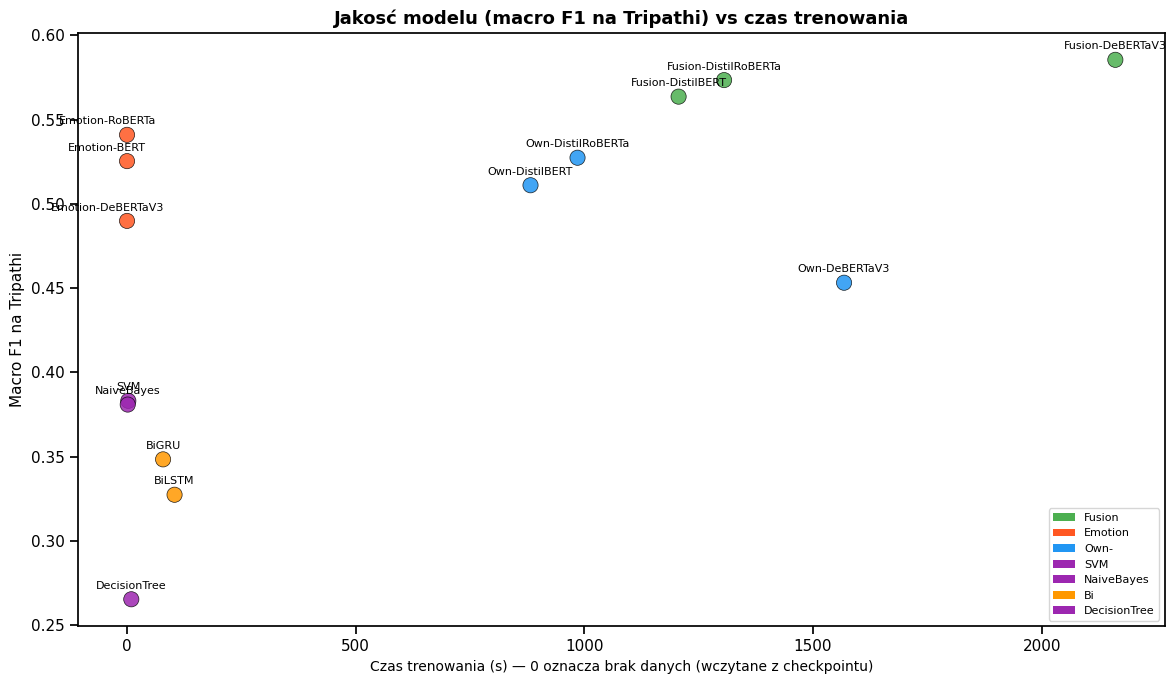

In [26]:
print('='*70)
print('Czasy trenowania poszczególnych modeli')
print('='*70)

if TRAINING_TIMES_PATH.exists():
    times = json.loads(TRAINING_TIMES_PATH.read_text())
else:
    times = training_times

# Quality vs time --- WYŁĄCZNIE Tripathi (jeden wspólny dataset)
if len(times) > 0:
    times_df = pd.DataFrame.from_dict(times, orient='index').reset_index()
    times_df.columns = ['model', 'training_time_sec', 'timestamp']
    
    # Pobierz wyniki TYLKO dla Tripathi z obu źródeł
    all_perf = pd.read_csv(REPORTS_DIR / 'all_results.csv') if (REPORTS_DIR / 'all_results.csv').exists() else None
    ens_perf = pd.read_csv(REPORTS_DIR / 'ensemble_results.csv') if (REPORTS_DIR / 'ensemble_results.csv').exists() else None
    
    # Filtruj TYLKO Tripathi i połącz
    perf_list = []
    if all_perf is not None:
        tripathi_all = all_perf[all_perf['dataset'] == 'Tripathi'][['model', 'macro_f1']]
        if len(tripathi_all) > 0:
            perf_list.append(tripathi_all)
    if ens_perf is not None:
        tripathi_ens = ens_perf[ens_perf['dataset'] == 'Tripathi'][['model', 'macro_f1']]
        if len(tripathi_ens) > 0:
            perf_list.append(tripathi_ens)
    
    if perf_list:
        perf_all = pd.concat(perf_list, ignore_index=True)
        # Usuń duplikaty modeli (zachowaj pierwszą wartość)
        perf_all = perf_all.drop_duplicates(subset='model', keep='first')
    else:
        perf_all = pd.DataFrame(columns=['model', 'macro_f1'])
    
    # Merge z czasami (zachowaj WSZYSTKIE modele, nawet bez czasu)
    merged = perf_all.merge(times_df[['model', 'training_time_sec']], on='model', how='left')
    merged = merged.dropna(subset=['macro_f1']).sort_values('macro_f1', ascending=False)
    
    if len(merged) > 0:
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Kolorowanie wg kategorii
        color_map = {
            'Fusion': '#4CAF50', 'Own-': '#2196F3', 'Emotion': '#FF5722',
            'Bi': '#FF9800', 'SVM': '#9C27B0', 'NaiveBayes': '#9C27B0',
            'DecisionTree': '#9C27B0'
        }
        def get_color(m):
            for k, v in color_map.items():
                if k in m: return v
            return '#888'
        
        colors = [get_color(m) for m in merged['model']]
        
        # Dla modeli BEZ czasu trenowania ustaw wartość 0
        times = merged['training_time_sec'].fillna(0).values
        f1s = merged['macro_f1'].values
        
        scatter = ax.scatter(times, f1s, c=colors, s=120, alpha=0.85,
                            edgecolors='black', linewidth=0.5, zorder=5)
        
        for _, row in merged.iterrows():
            t = row['training_time_sec'] if pd.notna(row['training_time_sec']) else -max(times)*0.02
            ax.annotate(row['model'], (t, row['macro_f1']),
                       fontsize=8, ha='center', va='bottom', xytext=(0, 6),
                       textcoords='offset points', zorder=10)
        
        ax.set_xlabel('Czas trenowania (s) \u2014 0 oznacza brak danych (wczytane z checkpointu)', fontsize=10)
        ax.set_ylabel('Macro F1 na Tripathi', fontsize=11)
        ax.set_title('Jakos\u0107 modelu (macro F1 na Tripathi) vs czas trenowania', fontweight='bold', fontsize=13)
        
        # Legenda
        from matplotlib.patches import Patch
        unique_cats = {}
        for m in merged['model']:
            for k, v in color_map.items():
                if k in m:
                    unique_cats[k] = v
                    break
        ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in unique_cats.items()],
                 loc='lower right', fontsize=8)
        
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'quality_vs_time_Tripathi.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Brak danych Tripathi do wykresu jakos\u0107 vs czas.')


---

## Podsumowanie końcowe

Notebook zakończony. Wszystkie artefakty (modele, wykresy, raporty) zostały zapisane w odpowiednich katalogach.

**Pliki wynikowe:**
- `reports/all_results.csv` — metryki wszystkich modeli na wszystkich zbiorach testowych
- `reports/ensemble_results.csv` — metryki modeli Fusion na Ensemble Test
- `reports/training_times.json` — czasy trenowania
- `reports/model_ranking.csv` — ranking modeli
- `plots/*.png` — wszystkie wykresy
- `checkpoints/` — zapisane wagi modeli

---


In [27]:
print('='*70)
print('PODSUMOWANIE KOŃCOWE')
print('='*70)

print(f'Checkpointy: {len(list(CHECKPOINT_DIR.glob("*")))} plików')
print(f'Wykresy: {len(list(PLOTS_DIR.glob("*.png")))} plików')
print(f'Raporty: {len(list(REPORTS_DIR.glob("*")))} plików')

print('\nPliki wynikowe:')
print('Raporty:', [p.name for p in REPORTS_DIR.glob('*')])
print('Plots (ostatnie):', sorted([p.name for p in PLOTS_DIR.glob('*.png')])[-5:])

print('\n=== KONIEC ===')

PODSUMOWANIE KOŃCOWE
Checkpointy: 13 plików
Wykresy: 37 plików
Raporty: 12 plików

Pliki wynikowe:
Raporty: ['ensemble_results.csv', 'text_length_error_ISEAR.csv', '.ipynb_checkpoints', 'text_length_error_Tripathi.csv', 'all_results.csv', 'training_times.json', 'training_times.csv', 'model_ranking.csv', 'text_length_error_Combined_test.csv', 'ensemble_ranking.csv', 'text_length_error_GoEmotions.csv', 'xai_similarity.csv']
Plots (ostatnie): ['xai_LIME_Own-DistilBERT_sample0.png', 'xai_LIME_Own-DistilRoBERTa_sample0.png', 'xai_sim_cosine.png', 'xai_sim_jaccard.png', 'xai_sim_spearman.png']

=== KONIEC ===
